# Step 1

# 에너지 사용량 예측 AI 모델

**데이터셋**: KAMP 자원 최적화 AI 데이터셋 (okm_augumented_2021.csv)  
**출처**: www.kamp-ai.kr  
**목표**: 15분 단위 피크 전력(kW) 예측 → 연간 기본 전기료 절감

---

### 모델링 프로세스 요약

**Target**: `15분` (15분 단위 최대수요전력, 단위: kW)

**1단계** 데이터 로드 및 기본 정보 확인 (.info / .describe)  
**2단계** EDA — 분포 시각화, 타겟 분포, 생산량-전력 관계  
**3단계** 결측치 / 이상치 확인 및 처리  
**4단계** 상관관계 분석 (Heatmap)  
**5단계** 변수 조합 설계 — Feature Set A / B / C  
**6단계** Train / Test Split + 스케일링  
**7단계** 모델 학습 — LinearReg / Ridge / DecisionTree / RandomForest / XGBoost / DNN  
**8단계** 하이퍼파라미터 튜닝 (GridSearchCV / RandomizedSearchCV)  
**9단계** 최종 모델 선정 및 종합 평가  
**10단계** 모델 저장 (pipeline.pkl)

# Step 2

In [119]:
import subprocess
import sys

required = {
    'xgboost'       : 'xgboost',
    'sklearn'       : 'scikit-learn',
    'pandas'        : 'pandas',
    'numpy'         : 'numpy',
    'matplotlib'    : 'matplotlib',
    'seaborn'       : 'seaborn',
    'joblib'        : 'joblib',
}

print("=== 라이브러리 설치 확인 ===\n")
for import_name, pkg_name in required.items():
    try:
        __import__(import_name)
        print(f"  ✅ {pkg_name:20s} 이미 설치됨")
    except ImportError:
        print(f"  ⚙️  {pkg_name:20s} 설치 중...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg_name, '--break-system-packages', '-q'])
        print(f"  ✅ {pkg_name:20s} 설치 완료")

print("\n✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!")

=== 라이브러리 설치 확인 ===

  ✅ xgboost              이미 설치됨
  ✅ scikit-learn         이미 설치됨
  ✅ pandas               이미 설치됨
  ✅ numpy                이미 설치됨
  ✅ matplotlib           이미 설치됨
  ✅ seaborn              이미 설치됨
  ✅ joblib               이미 설치됨

✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!


# 필요 라이브러리 설치 확인 (최초 1회만 실행)
# !pip install xgboost --break-system-packages
# !pip install scikit-learn --break-system-packages

# Step 3

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4
✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4


# Step 4

In [121]:
import os

# 현재 작업 디렉토리 확인
print(f"현재 작업 경로: {os.getcwd()}")

현재 작업 경로: c:\Users\Admin\hipython\ml


In [122]:
import os
import pandas as pd

# 가능한 경로 후보 목록
candidates = [
    r'C:\Users\Admin\hipython\data\okm_augumented_2021.csv',
    r'C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv',
    './data/okm_augumented_2021.csv',
]

# 존재하는 경로 자동 탐지
file_path = None
for path in candidates:
    if os.path.exists(path):
        file_path = path
        print(f"✅ 파일 발견: {file_path}")
        break

if file_path is None:
    print("❌ 파일을 찾지 못했습니다. 경로를 확인하세요.")
    print(f"   현재 작업 경로: {os.getcwd()}")
else:
    df = pd.read_csv(file_path)
    print(f"\n✅ 데이터 로드 완료")
    print(f"   행(row) 수 : {df.shape[0]:,}")
    print(f"   열(col) 수 : {df.shape[1]}")
    print()
    print("=== 컬럼 목록 ===")
    print(df.columns.tolist())
    print()
    print("=== 상위 5행 ===")
    display(df.head())

✅ 파일 발견: C:\Users\Admin\hipython\data\okm_augumented_2021.csv

✅ 데이터 로드 완료
   행(row) 수 : 6,168
   열(col) 수 : 18

=== 컬럼 목록 ===
['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

=== 상위 5행 ===


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


# Step 5

In [123]:
print("=== .info() — 컬럼별 타입 및 결측치 ===")
df.info()

=== .info() — 컬럼별 타입 및 결측치 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


# Step 6

In [124]:
print("=== .describe() — 기술통계 ===")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

=== .describe() — 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
날짜,6168.000000,20210492.299611,244.775577,20210101.000000,20210306.000000,20210509.000000,20210712.000000,20210914.000000
시간,6168.000000,12.428016,12.847309,0.000000,6.000000,12.000000,18.000000,188.000000
15분,6168.000000,90.410182,55.349403,0.000000,23.000000,101.000000,133.000000,207.000000
30분,6168.000000,92.695363,57.942122,0.000000,23.000000,104.000000,143.000000,222.000000
45분,6168.000000,95.106355,59.285709,0.000000,23.000000,105.000000,149.000000,218.000000
60분,6168.000000,95.037938,59.347554,0.000000,23.000000,107.000000,149.000000,214.000000
평균,6168.000000,93.424125,57.355938,0.000000,23.000000,104.000000,144.000000,208.000000
생산량,6168.000000,467.344682,857.571815,0.000000,0.000000,45.000000,637.250000,9830.000000
기온,6168.000000,15.906064,9.160356,-12.000000,9.600000,17.400000,23.300000,33.400000
풍속,6165.000000,2.063633,1.164118,0.000000,1.200000,1.900000,2.800000,7.600000


# Step 7

In [125]:
print("=== 결측치 현황 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측률(%)': missing_pct
}).query('`결측치 수` > 0')

print(missing_df)
print(f"\n총 결측치 수 : {missing.sum()}개")
print(f"결측치 있는 컬럼 : {len(missing_df)}개")

=== 결측치 현황 ===
      결측치 수  결측률(%)
풍속        3    0.05
강수량       1    0.02
공장인원     17    0.28

총 결측치 수 : 21개
결측치 있는 컬럼 : 3개


# Step 8

=== 이상치 확인 ===
[시간] 최대값: 188  (정상: 0~23)
       시간 > 23 인 행: 48건

[15분 피크전력] 최소: 0 / 최대: 207 / 평균: 90.4
                피크전력 = 0 인 행: 19건

[생산량] 0인 행: 2657건 (43.1%)  ← 비가동 시간

[공장인원] 최소: 0.00 / 최대: 48.39



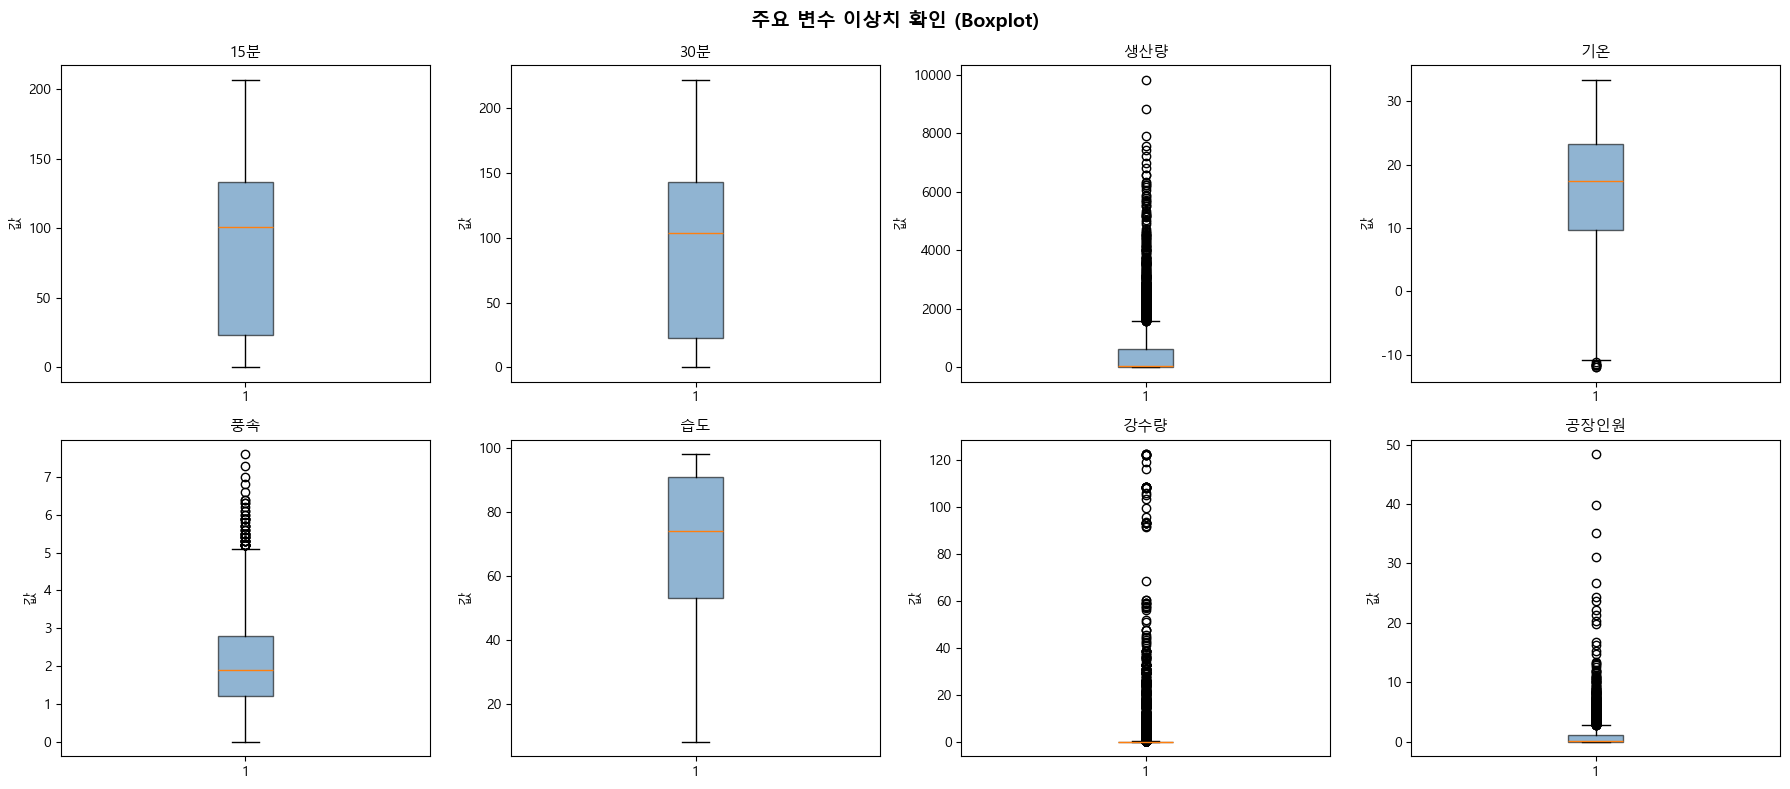

In [126]:
print("=== 이상치 확인 ===")

# 1) 시간 컬럼: 0~23이 정상
print(f"[시간] 최대값: {df['시간'].max()}  (정상: 0~23)")
print(f"       시간 > 23 인 행: {(df['시간'] > 23).sum()}건")
print()

# 2) 타겟 변수 분포
print(f"[15분 피크전력] 최소: {df['15분'].min()} / 최대: {df['15분'].max()} / 평균: {df['15분'].mean():.1f}")
print(f"                피크전력 = 0 인 행: {(df['15분'] == 0).sum()}건")
print()

# 3) 생산량 0 비율
print(f"[생산량] 0인 행: {(df['생산량'] == 0).sum()}건 ({(df['생산량'] == 0).mean()*100:.1f}%)  ← 비가동 시간")
print()

# 4) 공장인원 분포
print(f"[공장인원] 최소: {df['공장인원'].min():.2f} / 최대: {df['공장인원'].max():.2f}")
print()

# 5) 박스플롯으로 수치 변수 이상치 시각화
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('주요 변수 이상치 확인 (Boxplot)', fontsize=14, fontweight='bold')

cols_to_check = ['15분', '30분', '생산량', '기온', '풍속', '습도', '강수량', '공장인원']
for ax, col in zip(axes.flatten(), cols_to_check):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('값')

plt.tight_layout()
plt.show()

# Step 9

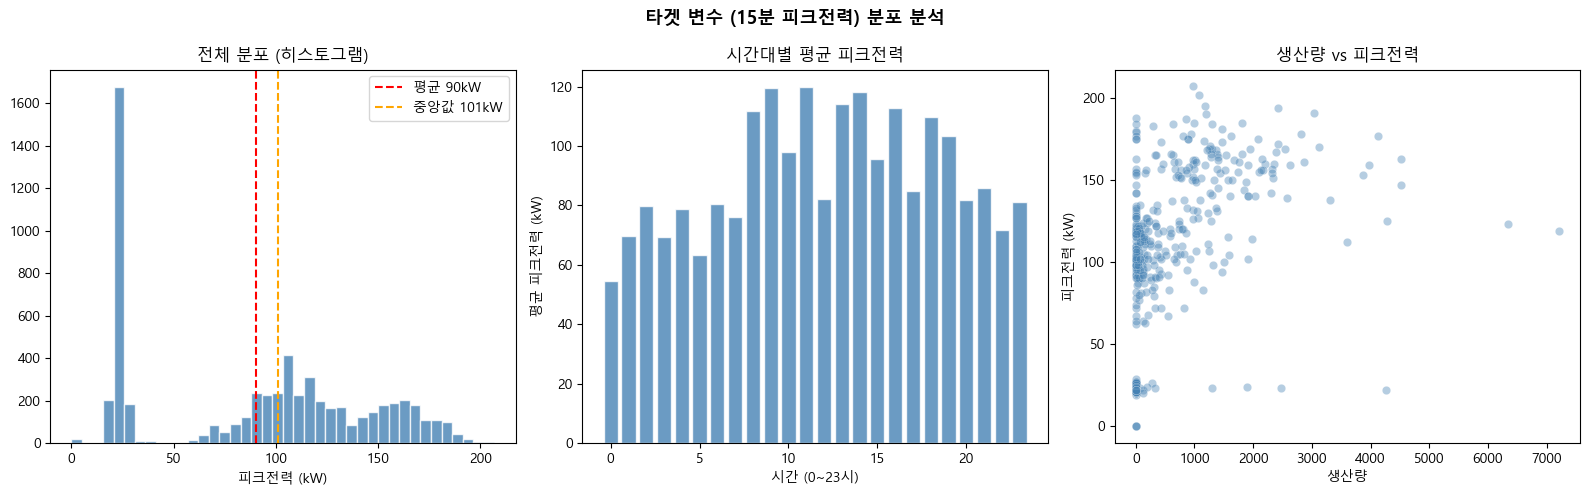


피크전력 고위험(≥130kW) 비율 : 26.9%


In [127]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('타겟 변수 (15분 피크전력) 분포 분석', fontsize=13, fontweight='bold')

# 1) 히스토그램
axes[0].hist(df['15분'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['15분'].mean(),   color='red',    linestyle='--', label=f"평균 {df['15분'].mean():.0f}kW")
axes[0].axvline(df['15분'].median(), color='orange', linestyle='--', label=f"중앙값 {df['15분'].median():.0f}kW")
axes[0].set_title('전체 분포 (히스토그램)')
axes[0].set_xlabel('피크전력 (kW)')
axes[0].legend()

# 2) 시간대별 평균 피크전력
hourly = df[df['시간'] <= 23].groupby('시간')['15분'].mean()
axes[1].bar(hourly.index, hourly.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('시간대별 평균 피크전력')
axes[1].set_xlabel('시간 (0~23시)')
axes[1].set_ylabel('평균 피크전력 (kW)')

# 3) 생산량 vs 피크전력 산점도
sample = df[df['시간'] <= 23].sample(500, random_state=42)
axes[2].scatter(sample['생산량'], sample['15분'],
                alpha=0.4, color='steelblue', edgecolor='white', linewidth=0.3)
axes[2].set_title('생산량 vs 피크전력')
axes[2].set_xlabel('생산량')
axes[2].set_ylabel('피크전력 (kW)')

plt.tight_layout()
plt.show()

print(f"\n피크전력 고위험(≥130kW) 비율 : {(df['15분'] >= 130).mean()*100:.1f}%")

# Step 10

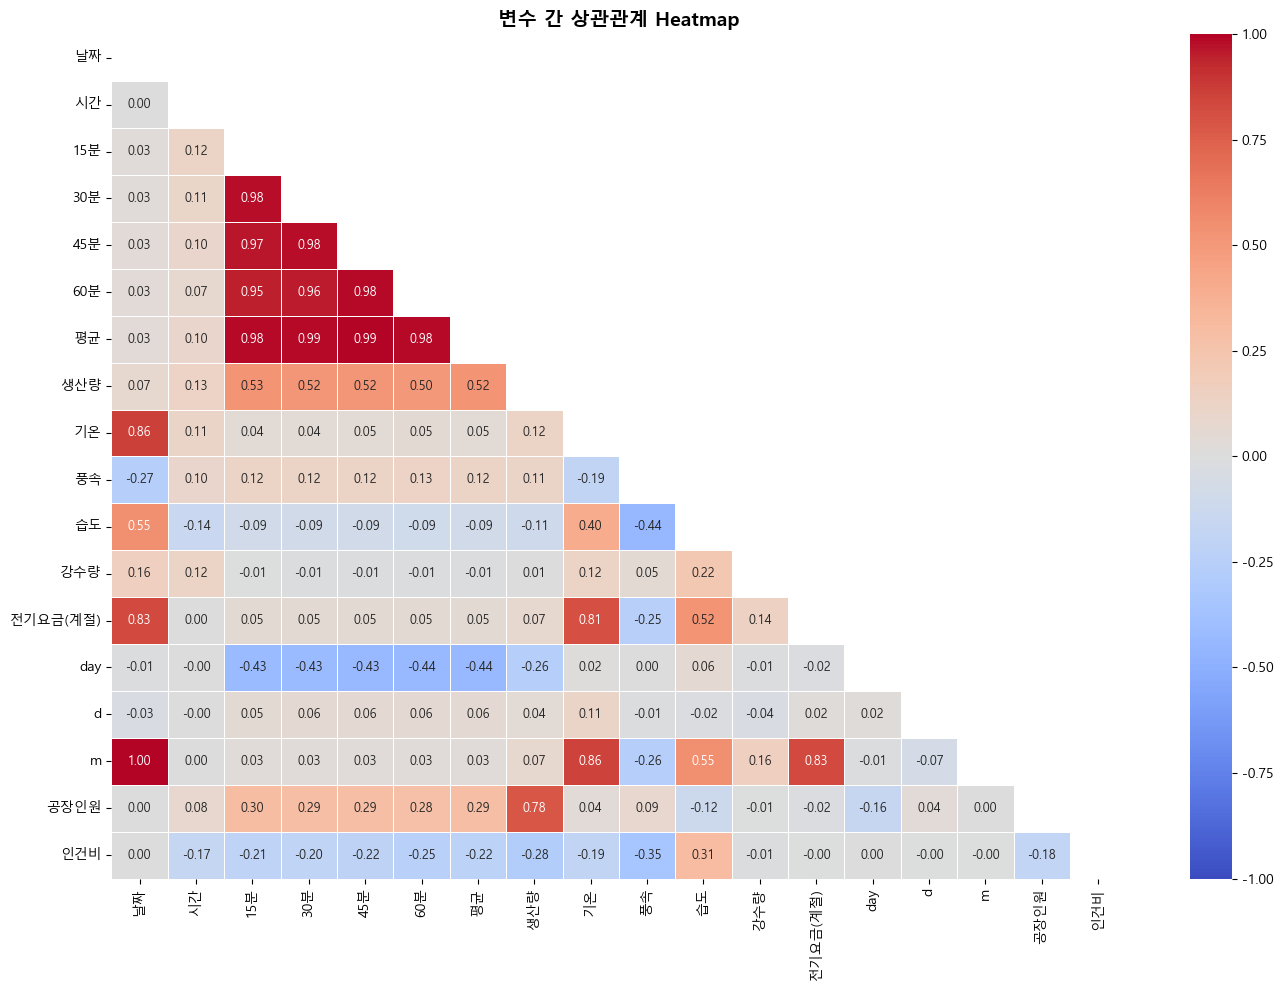

=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===
생산량         0.526266
day         0.427823
공장인원        0.299105
인건비         0.208396
시간          0.120790
풍속          0.119570
습도          0.089654
d           0.053607
전기요금(계절)    0.050699
기온          0.043692
날짜          0.030397
m           0.028410
강수량         0.006896


In [128]:
# 이상치 제거 후 상관관계 계산
df_corr = df[df['시간'] <= 23].copy()

# 상관행렬
corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('변수 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 타겟(15분)과의 상관계수 순위
print("=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===")
target_corr = corr_matrix['15분'].drop(['15분','30분','45분','60분','평균']).abs()
print(target_corr.sort_values(ascending=False).to_string())

# Step 11

In [129]:
# ── 전처리 ────────────────────────────────────────────
df_clean = df.copy()

# 1) 이상치 제거: 시간 > 23
before = len(df_clean)
df_clean = df_clean[df_clean['시간'] <= 23]
print(f"[이상치 제거] 시간>23: {before - len(df_clean)}행 제거 → 잔여 {len(df_clean):,}행")

# 2) 결측치 처리
df_clean['풍속']   = df_clean['풍속'].fillna(df_clean['풍속'].median())
df_clean['강수량']  = df_clean['강수량'].fillna(0)   # 강수 없음으로 대체
df_clean['공장인원'] = df_clean['공장인원'].fillna(0)  # 비가동으로 대체
print(f"[결측치 처리] 완료 — 남은 결측치: {df_clean.isnull().sum().sum()}개")

# 3) 타겟 / 피처 분리
# ※ 30분/45분/60분/평균은 Data Leakage → 반드시 제외
TARGET = '15분'
LEAK_COLS = ['30분', '45분', '60분', '평균']  # 타겟과 같은 계열 → 제외
DROP_COLS  = ['날짜'] + LEAK_COLS              # 날짜는 시계열 특성 대신 d/m으로 대체

feature_cols = [c for c in df_clean.columns if c not in [TARGET] + DROP_COLS]

X = df_clean[feature_cols].copy()
y = df_clean[TARGET].copy()

print(f"\n[피처 구성]")
print(f"  사용 피처 수 : {len(feature_cols)}개")
print(f"  피처 목록    : {feature_cols}")
print(f"\n  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"\n  타겟(y) 통계 → 평균: {y.mean():.1f}kW / 최대: {y.max()}kW / 최소: {y.min()}kW")

[이상치 제거] 시간>23: 48행 제거 → 잔여 6,120행
[결측치 처리] 완료 — 남은 결측치: 0개

[피처 구성]
  사용 피처 수 : 12개
  피처 목록    : ['시간', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

  X shape : (6120, 12)
  y shape : (6120,)

  타겟(y) 통계 → 평균: 90.1kW / 최대: 207kW / 최소: 0kW


# Step 12

## 변수 조합 설계 — Feature Set A / B / C

현실에서 공장 담당자가 **예측 시점에 알 수 있는 정보**만으로 피처를 구성합니다.

| Feature Set | 변수 구성 | 설명 |
|---|---|---|
| **Set A (핵심)** | 시간, 생산량, 공장인원, day, d, m | 공정 핵심 변수만 |
| **Set B (핵심+환경)** | Set A + 기온, 습도, 풍속, 강수량 | 날씨 변수 추가 |
| **Set C (전체)** | 전체 12개 변수 | 전기요금(계절), 인건비 포함 |

→ 3가지 Feature Set을 모두 학습해서 변수 추가 효과를 비교합니다.

# Step 13

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

print(f"\n✅ Split 완료")
print(f"   학습 데이터: {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")

=== Feature Set 구성 ===
  Set_A (6개): ['시간', '생산량', '공장인원', 'day', 'd', 'm']
  Set_B (10개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량']
  Set_C (12개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비']

✅ Split 완료
   학습 데이터: 4,896행
   테스트 데이터: 1,224행


# Step 14

In [131]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    """회귀 모델 성능 평가 지표 계산"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'모델': model_name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R²': round(r2,4)}

all_results = []   # 전체 결과 저장 리스트
print("✅ 평가 함수 정의 완료")

✅ 평가 함수 정의 완료


# Step 15

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

# ── 결과 저장 리스트 초기화 ───────────────────────────
all_results = []

print(f"\n✅ Split 완료")
print(f"   학습 데이터  : {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")
print(f"   all_results  : 초기화 완료")

=== Feature Set 구성 ===
  Set_A (6개): ['시간', '생산량', '공장인원', 'day', 'd', 'm']
  Set_B (10개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량']
  Set_C (12개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비']

✅ Split 완료
   학습 데이터  : 4,896행
   테스트 데이터: 1,224행
   all_results  : 초기화 완료


# Step 16

In [133]:
from sklearn.tree import DecisionTreeRegressor

print("=" * 55)
print("  [모델 3] Decision Tree Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    dt.fit(Xtr, y_train)
    res = evaluate_model(f'DecisionTree [{fs_name}]', y_test, dt.predict(Xte))
    all_results.append(res)
    print(f"  DecisionTree {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

print()
print("💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상")
print("   단, 단일 트리는 분기점에서 과적합 가능성 존재")
print("   → Random Forest(앙상블)로 개선 가능")

  [모델 3] Decision Tree Regressor
  DecisionTree Set_A  | RMSE= 16.89 | MAE=  9.45 | R²=0.9102
  DecisionTree Set_B  | RMSE= 18.50 | MAE= 10.26 | R²=0.8923
  DecisionTree Set_C  | RMSE= 18.51 | MAE= 10.28 | R²=0.8922

💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상
   단, 단일 트리는 분기점에서 과적합 가능성 존재
   → Random Forest(앙상블)로 개선 가능


# Step 17

In [134]:
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  [모델 4] Random Forest Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(Xtr, y_train)
    res = evaluate_model(f'RandomForest [{fs_name}]', y_test, rf.predict(Xte))
    all_results.append(res)
    print(f"  RandomForest {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장 (Feature Importance용)
rf_setC = RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_setC.fit(splits['Set_C']['X_train'], y_train)

print()
print("💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능")
print("   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제")

  [모델 4] Random Forest Regressor
  RandomForest Set_A  | RMSE= 13.07 | MAE=  7.53 | R²=0.9463
  RandomForest Set_B  | RMSE= 14.19 | MAE=  8.46 | R²=0.9366
  RandomForest Set_C  | RMSE= 14.26 | MAE=  8.47 | R²=0.9359

💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능
   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제


# Step 18

In [135]:
from xgboost import XGBRegressor

print("=" * 55)
print("  [모델 5] XGBoost Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb.fit(Xtr, y_train,
            eval_set=[(Xte, y_test)],
            verbose=False)
    res = evaluate_model(f'XGBoost [{fs_name}]', y_test, xgb.predict(Xte))
    all_results.append(res)
    print(f"  XGBoost {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장
xgb_setC = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0)
xgb_setC.fit(splits['Set_C']['X_train'], y_train, verbose=False)

print()
print("💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)")
print("   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습")
print("   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지")

  [모델 5] XGBoost Regressor
  XGBoost Set_A  | RMSE= 12.36 | MAE=  7.94 | R²=0.9519
  XGBoost Set_B  | RMSE= 13.20 | MAE=  8.30 | R²=0.9451
  XGBoost Set_C  | RMSE= 13.33 | MAE=  8.47 | R²=0.9441

💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)
   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습
   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지


# Step 19

In [136]:
from sklearn.neural_network import MLPRegressor

print("=" * 55)
print("  [모델 6] DNN (sklearn MLPRegressor)")
print("=" * 55)
print("  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용")
print()

dnn_configs = {
    'DNN-Shallow [64]'       : (64,),
    'DNN-Medium  [128,64]'   : (128, 64),
    'DNN-Deep    [128,64,32]': (128, 64, 32),
}

# Set_C 기준으로만 DNN 실행
Xtr_sc = splits['Set_C']['X_train_sc']
Xte_sc = splits['Set_C']['X_test_sc']

for dnn_name, layers in dnn_configs.items():
    dnn = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,       # 과적합 방지 자동 조기종료
        validation_fraction=0.1,   # train의 10%를 검증용으로 사용
        random_state=42
    )
    dnn.fit(Xtr_sc, y_train)
    res = evaluate_model(f'{dnn_name} [Set_C]', y_test, dnn.predict(Xte_sc))
    all_results.append(res)
    print(f"  {dnn_name} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")
    print(f"              → 실제 학습 에포크: {dnn.n_iter_}회 (early stopping)")

# 최적 DNN 저장 (Medium)
dnn_best = MLPRegressor(hidden_layer_sizes=(128,64), activation='relu',
                        solver='adam', max_iter=500, early_stopping=True,
                        validation_fraction=0.1, random_state=42)
dnn_best.fit(Xtr_sc, y_train)

print()
print("💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)")
print("   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습")
print("   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료")
print("   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음")
print("      (DNN은 수십만 행 이상에서 진가 발휘)")

  [모델 6] DNN (sklearn MLPRegressor)
  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용

  DNN-Shallow [64] | RMSE= 30.98 | MAE= 24.02 | R²=0.6979
              → 실제 학습 에포크: 500회 (early stopping)
  DNN-Medium  [128,64] | RMSE= 20.99 | MAE= 14.65 | R²=0.8613
              → 실제 학습 에포크: 354회 (early stopping)
  DNN-Deep    [128,64,32] | RMSE= 21.59 | MAE= 15.26 | R²=0.8532
              → 실제 학습 에포크: 168회 (early stopping)

💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)
   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습
   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료
   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음
      (DNN은 수십만 행 이상에서 진가 발휘)


# Step 20

In [137]:
results_df = pd.DataFrame(all_results)

print("=" * 65)
print("  전체 모델 × Feature Set 비교표 (R² 내림차순)")
print("=" * 65)
print(results_df.sort_values('R²', ascending=False).to_string(index=False))

  전체 모델 × Feature Set 비교표 (R² 내림차순)
                             모델  RMSE   MAE     R²
                XGBoost [Set_A] 12.36  7.94 0.9519
           RandomForest [Set_A] 13.07  7.53 0.9463
                XGBoost [Set_B] 13.20  8.30 0.9451
                XGBoost [Set_C] 13.33  8.47 0.9441
           RandomForest [Set_B] 14.19  8.46 0.9366
           RandomForest [Set_C] 14.26  8.47 0.9359
           DecisionTree [Set_A] 16.89  9.45 0.9102
           DecisionTree [Set_B] 18.50 10.26 0.8923
           DecisionTree [Set_C] 18.51 10.28 0.8922
   DNN-Medium  [128,64] [Set_C] 20.99 14.65 0.8613
DNN-Deep    [128,64,32] [Set_C] 21.59 15.26 0.8532
       DNN-Shallow [64] [Set_C] 30.98 24.02 0.6979


# Step 21

In [138]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — Random Forest (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

Xtr = splits['Set_C']['X_train']
Xte = splits['Set_C']['X_test']

param_dist_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.7],
}

rf_tuned = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_rf,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
rf_tuned.fit(Xtr, y_train)

print(f"\n✅ 최적 파라미터: {rf_tuned.best_params_}")
print(f"   CV R² (학습) : {rf_tuned.best_score_:.4f}")

res = evaluate_model('RF_Tuned [Set_C]', y_test, rf_tuned.predict(Xte))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — Random Forest (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
   CV R² (학습) : 0.9066
   Test  R²     : 0.9360 / RMSE: 14.26 / MAE: 8.72


# Step 22

In [139]:
from xgboost import XGBRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — XGBoost (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_tuned = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
xgb_tuned.fit(splits['Set_C']['X_train'], y_train)

print(f"\n✅ 최적 파라미터: {xgb_tuned.best_params_}")
print(f"   CV R² (학습) : {xgb_tuned.best_score_:.4f}")

res = evaluate_model('XGB_Tuned [Set_C]', y_test, xgb_tuned.predict(splits['Set_C']['X_test']))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — XGBoost (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
   CV R² (학습) : 0.9306
   Test  R²     : 0.9481 / RMSE: 12.84 / MAE: 8.0


# Step 23

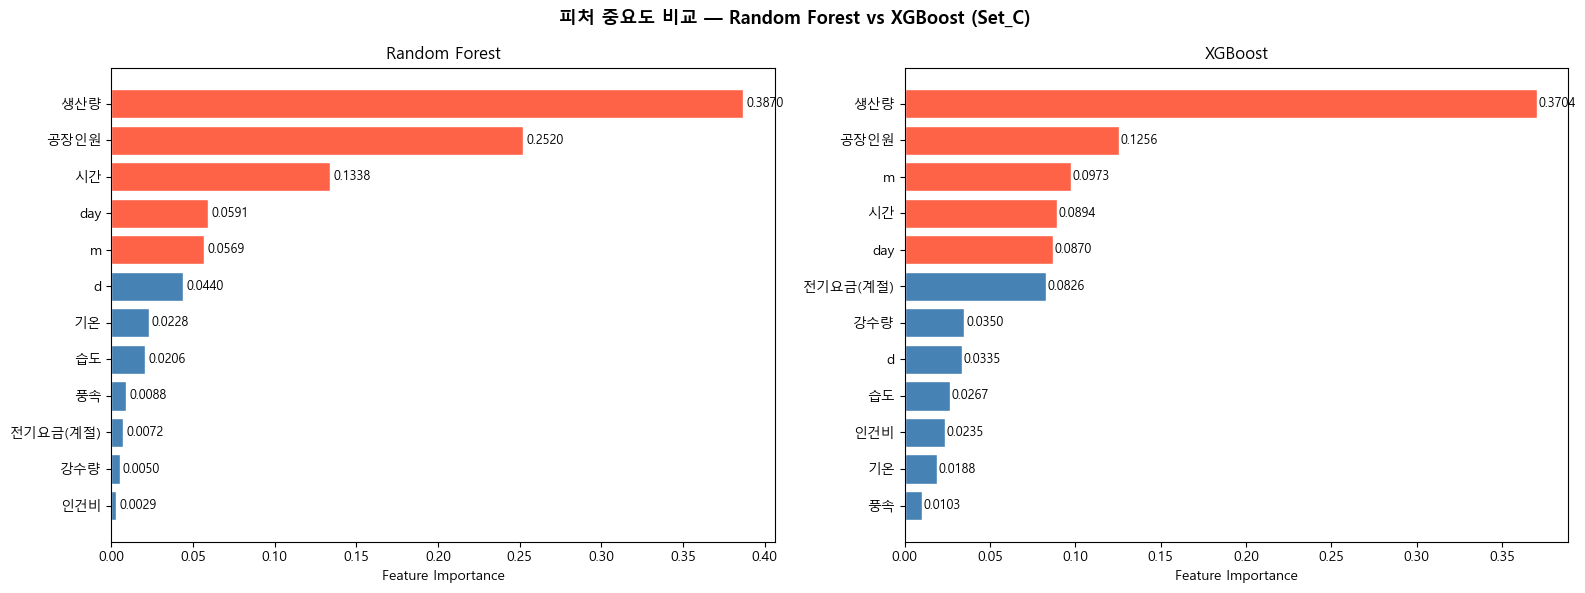


=== RF Feature Importance Top 5 ===
생산량     0.387022
공장인원    0.251998
시간      0.133800
day     0.059083
m       0.056860

=== XGBoost Feature Importance Top 5 ===
생산량     0.370351
공장인원    0.125598
m       0.097304
시간      0.089377
day     0.086957


In [140]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처 중요도 비교 — Random Forest vs XGBoost (Set_C)', fontsize=13, fontweight='bold')

feature_names = FEATURE_SETS['Set_C']

# RF Feature Importance
fi_rf = pd.Series(rf_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_rf = ['tomato' if v > fi_rf.quantile(0.6) else 'steelblue' for v in fi_rf.values]
axes[0].barh(fi_rf.index, fi_rf.values, color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest', fontsize=12)
axes[0].set_xlabel('Feature Importance')
for i, val in enumerate(fi_rf.values):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# XGBoost Feature Importance
fi_xgb = pd.Series(xgb_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_xgb = ['tomato' if v > fi_xgb.quantile(0.6) else 'steelblue' for v in fi_xgb.values]
axes[1].barh(fi_xgb.index, fi_xgb.values, color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost', fontsize=12)
axes[1].set_xlabel('Feature Importance')
for i, val in enumerate(fi_xgb.values):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RF Feature Importance Top 5 ===")
print(fi_rf.sort_values(ascending=False).head(5).to_string())
print("\n=== XGBoost Feature Importance Top 5 ===")
print(fi_xgb.sort_values(ascending=False).head(5).to_string())

# Step 24

  최종 모델 성능 비교 (Set_C 기준)
                             모델  RMSE   MAE     R²
              XGB_Tuned [Set_C] 12.84  8.00 0.9481
                XGBoost [Set_C] 13.33  8.47 0.9441
               RF_Tuned [Set_C] 14.26  8.72 0.9360
           RandomForest [Set_C] 14.26  8.47 0.9359
           DecisionTree [Set_C] 18.51 10.28 0.8922
   DNN-Medium  [128,64] [Set_C] 20.99 14.65 0.8613
DNN-Deep    [128,64,32] [Set_C] 21.59 15.26 0.8532
       DNN-Shallow [64] [Set_C] 30.98 24.02 0.6979


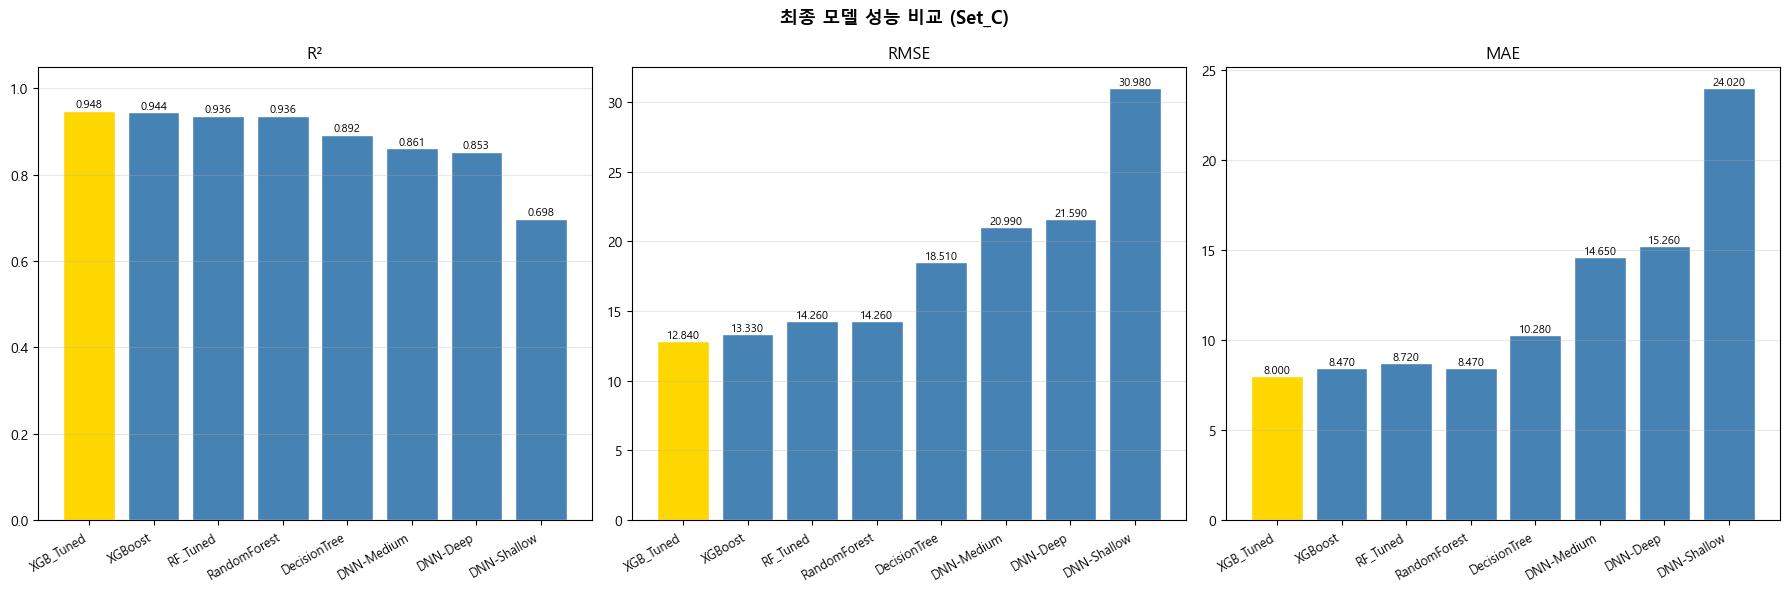

In [141]:
results_df = pd.DataFrame(all_results)

# Set_C 결과만 필터링해서 보기
setC_results = results_df[results_df['모델'].str.contains('Set_C')].sort_values('R²', ascending=False)

print("=" * 65)
print("  최종 모델 성능 비교 (Set_C 기준)")
print("=" * 65)
print(setC_results.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('최종 모델 성능 비교 (Set_C)', fontsize=13, fontweight='bold')

model_labels = [m.split('[')[0].strip() for m in setC_results['모델']]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(setC_results))]

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(model_labels, setC_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xticklabels(model_labels, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, setC_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'R²':
        ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Step 25

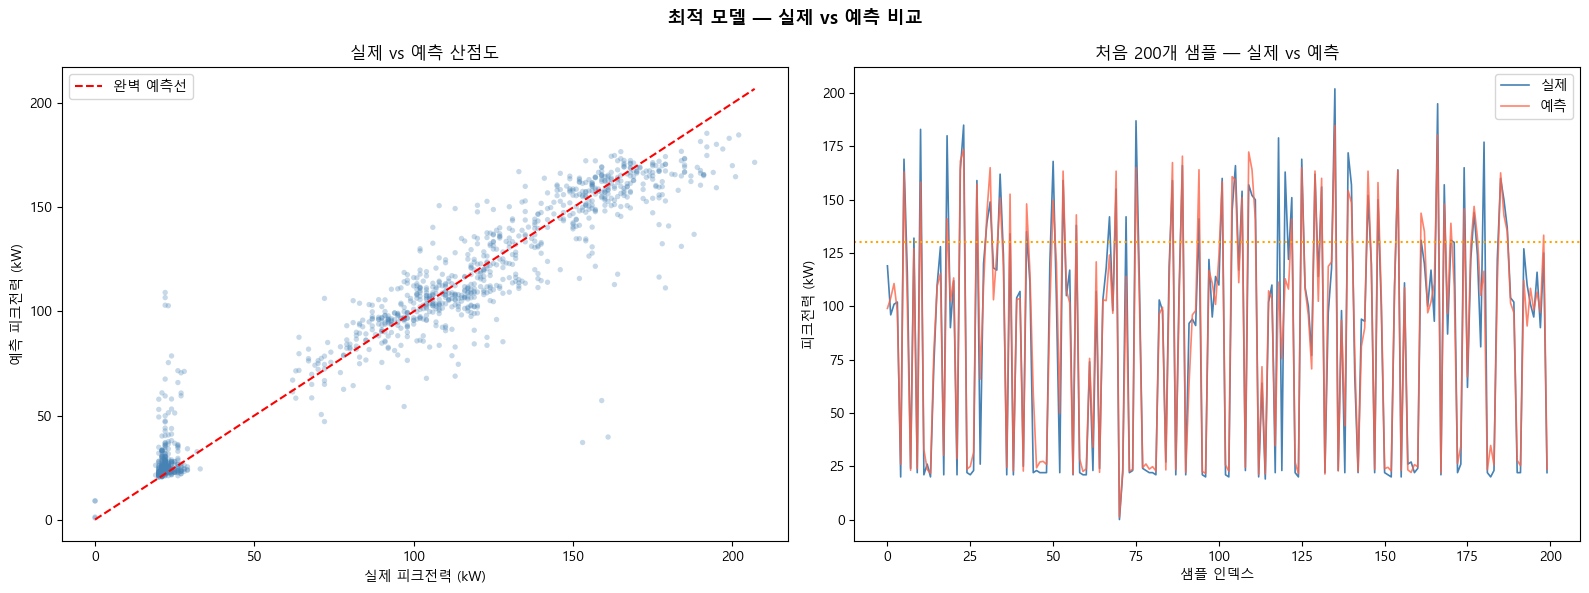


최적 모델 최종 성능
  RMSE : 14.26 kW  (평균 피크 90kW 대비 오차율 15.8%)
  R²   : 0.9360


In [142]:
# 최적 모델로 예측
best_model = rf_tuned   # RF_Tuned 또는 XGB_Tuned 중 R²가 높은 것
y_pred_best = best_model.predict(splits['Set_C']['X_test'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('최적 모델 — 실제 vs 예측 비교', fontsize=13, fontweight='bold')

# 1) 산점도
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', edgecolor='none', s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='완벽 예측선')
axes[0].set_xlabel('실제 피크전력 (kW)')
axes[0].set_ylabel('예측 피크전력 (kW)')
axes[0].set_title('실제 vs 예측 산점도')
axes[0].legend()

# 2) 처음 200개 시계열 비교
idx = range(200)
axes[1].plot(idx, list(y_test)[:200],      label='실제', color='steelblue', linewidth=1.2)
axes[1].plot(idx, y_pred_best[:200], label='예측', color='tomato',    linewidth=1.2, alpha=0.8)
axes[1].set_xlabel('샘플 인덱스')
axes[1].set_ylabel('피크전력 (kW)')
axes[1].set_title('처음 200개 샘플 — 실제 vs 예측')
axes[1].legend()
axes[1].axhline(130, color='orange', linestyle=':', linewidth=1.5, label='고피크 기준(130kW)')

plt.tight_layout()
plt.show()

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"\n최적 모델 최종 성능")
print(f"  RMSE : {rmse_final:.2f} kW  (평균 피크 90kW 대비 오차율 {rmse_final/y.mean()*100:.1f}%)")
print(f"  R²   : {r2_score(y_test, y_pred_best):.4f}")

# Step 26

In [143]:
import joblib
import os
from sklearn.pipeline import Pipeline

os.makedirs('./models', exist_ok=True)

# 최적 파라미터로 파이프라인 구성
best_params = rf_tuned.best_params_

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),                        # 스케일링 (RF는 불필요하지만 통일성 유지)
    ('model' , RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Set_C 피처로 재학습
final_pipeline.fit(splits['Set_C']['X_train'], y_train)

# 저장
save_path = './models/energy_pipeline.pkl'
joblib.dump({
    'pipeline'    : final_pipeline,
    'feature_cols': FEATURE_SETS['Set_C'],
    'scaler'      : scalers['Set_C'],
    'best_params' : best_params,
}, save_path)

size_mb = os.path.getsize(save_path) / (1024**2)
print(f"✅ 모델 저장 완료: {save_path}  ({size_mb:.2f} MB)")

# 로드 후 검증
loaded = joblib.load(save_path)
y_check = loaded['pipeline'].predict(splits['Set_C']['X_test'])
print(f"   로드 후 R² 검증: {r2_score(y_test, y_check):.4f}  ✅")

✅ 모델 저장 완료: ./models/energy_pipeline.pkl  (67.00 MB)
   로드 후 R² 검증: 0.9360  ✅


In [144]:
# 확인용 셀
import pandas as pd

asos_path = r'C:\Users\Admin\hipython\ml\data\asos_solar_2021.csv'
df_check = pd.read_csv(asos_path)
print(f"행 수: {len(df_check):,}")
print(f"날짜 범위: {df_check['날짜_key'].min()} ~ {df_check['날짜_key'].max()}")
print(f"월별 행 수:")
df_check['월'] = df_check['날짜_key'].astype(str).str[4:6].astype(int)
print(df_check.groupby('월').size().to_string())

행 수: 8,760
날짜 범위: 20210101 ~ 20211231
월별 행 수:
월
1     744
2     672
3     744
4     720
5     744
6     720
7     744
8     744
9     720
10    744
11    720
12    744


# Step 27 데이터 증강 9개월 -> 1년 

In [173]:
# ================================================
# Step 27: 방법3 개선 — OBS 울산 실제 날씨 기반
# 원본(1/1~9/14) 완전 보존
# 확장(9/15~12/31): OBS 실제날씨 + Top6 규칙 + 추석·공휴일
# ================================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

np.random.seed(42)

# ── 원본 OKM 로드 ─────────────────────────────────
for p in [r'C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv',
          r'C:\Users\Admin\hipython\data\okm_augumented_2021.csv']:
    if os.path.exists(p):
        df_okm = pd.read_csv(p)
        print(f"OKM 로드: {p}")
        break

df_okm = df_okm[df_okm['시간']<=23].copy()
df_okm['공장인원'] = df_okm['공장인원'].fillna(0)
df_okm['강수량']   = df_okm['강수량'].fillna(0)
df_okm['풍속']     = df_okm['풍속'].fillna(df_okm['풍속'].median())

# 시간 이상치 재매핑 (행 제거 아닌 수정 방식 — 15번 방식 적용)
err_dates = df_okm[
    (df_okm['시간']<0)|(df_okm['시간']>23)
]['날짜'].unique().tolist()
for date in err_dates:
    df_okm.loc[df_okm['날짜']==date, '시간'] = list(range(24))
print(f"시간 이상치 수정: {len(err_dates)}개 날짜")

# ── OBS 울산 날씨 로드 ───────────────────────────
obs_path = r'C:\Users\Admin\hipython\ml\data\OBS_ASOS_TIM_20260319115729.csv'
df_obs = pd.read_csv(obs_path, encoding='cp949')
df_obs['일시']     = pd.to_datetime(df_obs['일시'])
df_obs['날짜_key'] = df_obs['일시'].dt.strftime('%Y%m%d').astype(int)
df_obs['시간_key'] = df_obs['일시'].dt.hour
df_obs = df_obs.rename(columns={
    '기온(°C)' :'asos_ta',
    '풍속(m/s)':'asos_ws',
    '습도(%)'  :'asos_hm',
    '강수량(mm)':'asos_rn',
})
df_obs['asos_rn'] = df_obs['asos_rn'].fillna(0)
df_obs['asos_ws'] = df_obs['asos_ws'].fillna(df_obs['asos_ws'].median())
print(f"OBS 로드: {len(df_obs):,}행 | {df_obs['날짜_key'].min()}~{df_obs['날짜_key'].max()}")

# ── ASOS solar_MJ 병합 (일사량은 기존 파일 사용) ──
asos_path = r'C:\Users\Admin\hipython\ml\data\asos_solar_2021.csv'
if os.path.exists(asos_path):
    df_asos = pd.read_csv(asos_path)
    df_asos['날짜_key'] = df_asos['날짜_key'].astype(int)
    df_asos['시간_key'] = df_asos['시간_key'].astype(int)
    solar_dict = df_asos.set_index(
        ['날짜_key','시간_key'])['solar_MJ'].to_dict()
    df_obs['solar_MJ'] = df_obs.apply(
        lambda r: solar_dict.get(
            (int(r['날짜_key']), int(r['시간_key'])), 0.0), axis=1)
    print("solar_MJ 병합 완료")
else:
    df_obs['solar_MJ'] = 0.0
    print("solar_MJ 없음 → 0으로 처리")

# ── STEP 1: 원본 + OBS 일사량 병합 ───────────────
df_orig = df_okm.copy()
df_orig['날짜_key'] = df_orig['날짜'].astype(int)
df_orig['시간_key'] = df_orig['시간'].astype(int)
df_orig = df_orig.merge(
    df_obs[['날짜_key','시간_key','solar_MJ']],
    on=['날짜_key','시간_key'], how='left')
night = (df_orig['시간']<=5)|(df_orig['시간']>=19)
df_orig.loc[night & df_orig['solar_MJ'].isna(), 'solar_MJ'] = 0.0
df_orig['solar_MJ'] = (df_orig['solar_MJ']
    .interpolate().fillna(0).clip(lower=0))
df_orig = df_orig.drop(columns=['날짜_key','시간_key'])
print(f"원본 준비: {len(df_orig):,}행")

# ── STEP 2: 9/15~12/31 날짜 프레임 생성 ──────────
rows = []
cur  = datetime(2021, 9, 15)
while cur <= datetime(2021, 12, 31, 23):
    rows.append({'날짜': int(cur.strftime('%Y%m%d')),
                 '시간': cur.hour})
    cur += timedelta(hours=1)
df_ext = pd.DataFrame(rows)
df_ext['m']   = df_ext['날짜'].astype(str).str[4:6].astype(int)
df_ext['d']   = df_ext['날짜'].astype(str).str[6:8].astype(int)
df_ext['day'] = pd.to_datetime(
    df_ext['날짜'].astype(str), format='%Y%m%d').dt.weekday + 1
print(f"확장 기간: {len(df_ext):,}행")

# ── STEP 3: OBS 실제 날씨 병합 ───────────────────
df_ext['날짜_key'] = df_ext['날짜'].astype(int)
df_ext['시간_key'] = df_ext['시간'].astype(int)
df_ext = df_ext.merge(
    df_obs[['날짜_key','시간_key','solar_MJ',
            'asos_ta','asos_hm','asos_ws','asos_rn']],
    on=['날짜_key','시간_key'], how='left'
).rename(columns={
    'asos_ta':'기온','asos_hm':'습도',
    'asos_ws':'풍속','asos_rn':'강수량'
})
night2 = (df_ext['시간']<=5)|(df_ext['시간']>=19)
df_ext.loc[night2 & df_ext['solar_MJ'].isna(), 'solar_MJ'] = 0.0
df_ext['solar_MJ'] = (df_ext['solar_MJ']
    .interpolate().fillna(0).clip(lower=0))
for c in ['기온','습도','풍속','강수량']:
    df_ext[c] = (df_ext[c]
        .interpolate()
        .fillna(method='bfill')
        .fillna(method='ffill'))
df_ext = df_ext.drop(columns=['날짜_key','시간_key'])
print(f"OBS 날씨 병합 완료 | "
      f"기온: {df_ext['기온'].min():.1f}~{df_ext['기온'].max():.1f}°C")

# ── STEP 4: 추석·공휴일 정의 (9/15~12/31) ────────
holidays_ext = [
    20210920,  # 추석
    20210921,  # 추석
    20210922,  # 추석
    20211003,  # 개천절
    20211004,  # 대체공휴일
    20211009,  # 한글날
    20211225,  # 크리스마스
]

# ── STEP 5: Top6 규칙 기반 생산량 생성 ───────────
winter = df_okm[df_okm['m'].isin([1,2])].copy()
winter['wd'] = pd.to_datetime(
    winter['날짜'].astype(str)+
    winter['시간'].astype(str).str.zfill(2),
    format='%Y%m%d%H').dt.weekday

prod_table   = winter.groupby(['wd','시간'])['생산량'].mean().reset_index()
worker_table = winter.groupby(['wd','시간'])['공장인원'].mean().reset_index()
prod_table.columns   = ['wd','시간','avg_prod']
worker_table.columns = ['wd','시간','avg_worker']

df_ext['wd'] = df_ext['day'] - 1
df_ext = df_ext.merge(prod_table,   on=['wd','시간'], how='left')
df_ext = df_ext.merge(worker_table, on=['wd','시간'], how='left')
df_ext['avg_prod']   = df_ext['avg_prod'].fillna(0)
df_ext['avg_worker'] = df_ext['avg_worker'].fillna(0)

# 공휴일·일요일 완전 휴무
holiday_mask = df_ext['날짜'].isin(holidays_ext)
sunday_mask  = df_ext['wd'] == 6
df_ext.loc[holiday_mask | sunday_mask,
           ['avg_prod','avg_worker']] = 0

# 토요일 50% 특근
sat_idx = df_ext.index[df_ext['wd']==5]
sat_off = sat_idx[np.random.random(len(sat_idx)) < 0.5]
df_ext.loc[sat_off, ['avg_prod','avg_worker']] = 0

# 노이즈 추가
df_ext['생산량'] = (
    df_ext['avg_prod'] +
    np.random.normal(0, df_ext['avg_prod']*0.05+2, len(df_ext))
).clip(lower=0).round().astype(int)
df_ext['공장인원'] = (
    df_ext['avg_worker'] +
    np.random.normal(0, 0.3, len(df_ext))
).clip(lower=0).round(2)
df_ext['인건비'] = df_ext['시간'].apply(
    lambda h: 1.5 if 8<=h<=18 else 1.0)
df_ext = df_ext.drop(columns=['wd','avg_prod','avg_worker'])

# ── STEP 6: 생산량 평균·표준편차 검증 ─────────────
orig_mean = df_okm['생산량'].mean()
orig_std  = df_okm['생산량'].std()
ext_mean  = df_ext['생산량'].mean()
print(f"\n=== 생산량 통계 검증 ===")
print(f"원본(1~9월) 평균: {orig_mean:.1f} / 표준편차: {orig_std:.1f}")
print(f"증강(9/15~12월) 평균: {ext_mean:.1f}")

# ── STEP 7: 전기요금·피크 생성 ───────────────────
def tariff(m):
    return (109.8 if m in [1,2,11,12]
            else 191.6 if m in [6,7,8] else 167.2)
df_ext['전기요금(계절)'] = df_ext['m'].apply(tariff)

def peak(prod, worker, h):
    if prod > 0:
        return max(0, 25 + min(prod/500*60,120)
                   + worker*3 + np.random.normal(0,8))
    if 8<=h<=18 and np.random.random()<0.15:
        return max(0, np.random.normal(75,20))
    return max(0, np.random.normal(25,5))

df_ext['15분'] = df_ext.apply(
    lambda r: round(peak(r['생산량'],r['공장인원'],r['시간']),1),
    axis=1)
df_ext['30분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['45분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['60분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['평균']  = ((df_ext['15분']+df_ext['30분']+
                   df_ext['45분']+df_ext['60분'])/4).round(1)

# ── STEP 8: 합치기 + 저장 ────────────────────────
okm_cols = list(df_okm.columns) + ['solar_MJ']
df_work  = pd.concat(
    [df_orig[okm_cols], df_ext[okm_cols]], ignore_index=True)
df_work  = df_work.sort_values(['날짜','시간']).reset_index(drop=True)

os.makedirs('./data', exist_ok=True)
df_work.to_csv('./data/okm_full_2021.csv', index=False, encoding='utf-8-sig')

print(f"\n=== 최종 요약 ===")
print(f"전체 행 수: {len(df_work):,}")
print(f"날짜 범위 : {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"컬럼 수   : {df_work.shape[1]}")
print(f"\n월별 평균 기온 (OBS 울산 실측):")
print(df_work.groupby('m')['기온'].mean().round(1).to_string())
print(f"\n월별 평균 생산량:")
print(df_work.groupby('m')['생산량'].mean().round(0).to_string())
print(f"\n전체 생산량 평균: {df_work['생산량'].mean():.1f}")
print(f"전체 생산량 표준편차: {df_work['생산량'].std():.1f}")
print(f"\n공휴일 반영 확인 (추석 9/20~22):")
for d in [20210920, 20210921, 20210922, 20211003, 20211009]:
    rows = df_work[df_work['날짜']==d]
    print(f"  {d}: 생산량 평균={rows['생산량'].mean():.0f} (0이면 정상)")
print(f"\n저장 완료: ./data/okm_full_2021.csv")
print("Step 27 완료")

OKM 로드: C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv
시간 이상치 수정: 0개 날짜
OBS 로드: 8,736행 | 20210101~20211231
solar_MJ 병합 완료
원본 준비: 6,120행
확장 기간: 2,592행
OBS 날씨 병합 완료 | 기온: -8.8~29.9°C

=== 생산량 통계 검증 ===
원본(1~9월) 평균: 471.0 / 표준편차: 859.9
증강(9/15~12월) 평균: 350.7

=== 최종 요약 ===
전체 행 수: 8,712
날짜 범위 : 20210101 ~ 20211231
컬럼 수   : 19

월별 평균 기온 (OBS 울산 실측):
m
1      2.0
2      6.5
3     10.5
4     13.8
5     17.7
6     21.6
7     25.9
8     25.3
9     22.1
10    17.1
11    11.1
12     4.8

월별 평균 생산량:
m
1     261.0
2     473.0
3     410.0
4     518.0
5     500.0
6     557.0
7     567.0
8     463.0
9     406.0
10    329.0
11    378.0
12    377.0

전체 생산량 평균: 435.2
전체 생산량 표준편차: 773.9

공휴일 반영 확인 (추석 9/20~22):
  20210920: 생산량 평균=1 (0이면 정상)
  20210921: 생산량 평균=1 (0이면 정상)
  20210922: 생산량 평균=1 (0이면 정상)
  20211003: 생산량 평균=0 (0이면 정상)
  20211009: 생산량 평균=1 (0이면 정상)

저장 완료: ./data/okm_full_2021.csv
Step 27 완료


In [175]:
import pandas as pd

# 로드
df = pd.read_csv('./data/okm_full_2021.csv')

# solar_MJ 제거
if 'solar_MJ' in df.columns:
    df = df.drop(columns=['solar_MJ'])

print(f"컬럼 수: {df.shape[1]}")
print(f"컬럼 목록: {df.columns.tolist()}")

# 새 파일명으로 먼저 저장
df.to_csv('./data/okm_full_2021_new.csv', index=False, encoding='utf-8-sig')
print("저장 완료: ./data/okm_full_2021_new.csv")

컬럼 수: 18
컬럼 목록: ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']
저장 완료: ./data/okm_full_2021_new.csv


In [177]:
import pandas as pd
import os
import time

# 잠깐 대기 후 시도
time.sleep(1)

try:
    os.remove('./data/okm_full_2021.csv')
    os.rename('./data/okm_full_2021_new.csv',
              './data/okm_full_2021.csv')
    print("파일 교체 완료")

    df_check = pd.read_csv('./data/okm_full_2021.csv')
    print(f"행 수: {len(df_check):,}")
    print(f"컬럼: {df_check.columns.tolist()}")
    print(f"solar_MJ 제거 확인: {'solar_MJ' not in df_check.columns}")

except PermissionError:
    print("아직 파일이 열려있습니다.")
    print("아래 중 하나를 확인해주세요:")
    print("1. 엑셀에서 okm_full_2021.csv 닫기")
    print("2. 윈도우 탐색기 미리보기 창 닫기")
    print("3. Jupyter 다른 탭에서 같은 파일 read_csv 실행 중인지 확인")
    print("닫은 후 이 셀 다시 실행하세요.")

파일 교체 완료
행 수: 8,712
컬럼: ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']
solar_MJ 제거 확인: True


# 확인용

In [146]:
print(f"행 수    : {len(df_work):,}")
print(f"날짜 범위: {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"월별 행수:")
print(df_work['m'].value_counts().sort_index())

행 수    : 8,712
날짜 범위: 20210101 ~ 20211231
월별 행수:
m
1     744
2     672
3     744
4     720
5     744
6     720
7     696
8     744
9     720
10    744
11    720
12    744
Name: count, dtype: int64


# Step 28: OBS 울산 기상 데이터 로드 및 df_work 준비

In [178]:
# ================================================
# Step 28: OBS 울산 기상 데이터 로드
# okm_full_2021.csv → df_work 로드
# ================================================
import pandas as pd
import numpy as np
import os

# ── OBS 울산 날씨 파일 로드 ───────────────────────
obs_path = r'C:\Users\Admin\hipython\ml\data\OBS_ASOS_TIM_20260319115729.csv'
df_obs = pd.read_csv(obs_path, encoding='cp949')

df_obs['일시']     = pd.to_datetime(df_obs['일시'])
df_obs['날짜_key'] = df_obs['일시'].dt.strftime('%Y%m%d').astype(int)
df_obs['시간_key'] = df_obs['일시'].dt.hour

df_obs = df_obs.rename(columns={
    '기온(°C)' : 'obs_ta',
    '풍속(m/s)': 'obs_ws',
    '습도(%)'  : 'obs_hm',
    '강수량(mm)': 'obs_rn',
})
df_obs['obs_rn'] = df_obs['obs_rn'].fillna(0)
df_obs['obs_ws'] = df_obs['obs_ws'].fillna(df_obs['obs_ws'].median())

print(f"OBS 로드 완료  : {len(df_obs):,}행")
print(f"OBS 날짜 범위  : {df_obs['날짜_key'].min()} ~ {df_obs['날짜_key'].max()}")
print(f"OBS 기온 범위  : {df_obs['obs_ta'].min():.1f} ~ {df_obs['obs_ta'].max():.1f}°C")

# ── okm_full_2021.csv → df_work 로드 ─────────────
df_work = pd.read_csv(r'C:\Users\Admin\hipython\ml\data\okm_full_2021.csv')

print(f"\ndf_work 로드 완료")
print(f"행 수  : {len(df_work):,}")
print(f"컬럼 수: {df_work.shape[1]}")
print(f"날짜 범위: {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"컬럼 목록: {df_work.columns.tolist()}")
print("\nStep 28 완료")

OBS 로드 완료  : 8,736행
OBS 날짜 범위  : 20210101 ~ 20211231
OBS 기온 범위  : -12.0 ~ 33.4°C

df_work 로드 완료
행 수  : 8,712
컬럼 수: 18
날짜 범위: 20210101 ~ 20211231
컬럼 목록: ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

Step 28 완료


# Step 29: GMM 생산구분(0~4) 파생변수 추가 (GMM 노트북 흡수)

In [179]:
# ================================================
# Step 29: GMM 생산구분(0~4) 파생변수 추가
# 15번 노트북 핵심 로직 흡수
# 생산량·공장인원·평균전력 3변수로 공정 패턴 자동 분류
# ================================================
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# ── 비가동 구간(구분0) 먼저 분리 ─────────────────
mask_zero = df_work['생산량'] <= 0
df_na     = df_work[mask_zero].copy()
df_na['GMM생산구분'] = 0

# ── 가동 구간 GMM 군집화 ──────────────────────────
df_target = df_work[~mask_zero].copy()

# 생산인력비율 계산 (제품 1000개당 투입 인원)
df_target['생산인력비율'] = (
    df_target['공장인원'] / (df_target['생산량'] / 1000)
).replace([np.inf, -np.inf], 0).fillna(0)

# GMM 입력 피처: 생산인력비율 + 평균전력
features = df_target[['생산인력비율', '평균']].fillna(0)
scaler_gmm = StandardScaler()
X_scaled   = scaler_gmm.fit_transform(features)

# GMM 학습 (3개 군집)
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# ── 라벨 → 생산구분 번호 매핑 ────────────────────
# 평균 전력 기준 내림차순: 1=고생산, 2=중생산, 3=저생산
label_power = {}
for lbl in set(labels):
    label_power[lbl] = df_target.loc[labels == lbl, '평균'].mean()

sorted_labels = sorted(label_power, key=lambda x: label_power[x], reverse=True)
final_map = {sorted_labels[i]: i+1 for i in range(len(sorted_labels))}
df_target['GMM생산구분'] = [final_map[l] for l in labels]

# ── 생산량 4,000 이상 → 구분2로 세분화 ──────────
df_target.loc[
    (df_target['GMM생산구분'] == 3) & (df_target['생산량'] > 4000),
    'GMM생산구분'] = 2

# ── 소량·야간 생산 → 구분4 ───────────────────────
df_target.loc[
    (df_target['GMM생산구분'] == 3) &
    (df_target['공장인원'] > 4) &
    (df_target['평균'] < 30),
    'GMM생산구분'] = 4

# ── 합치기 → df_work 반영 ────────────────────────
df_combined = pd.concat([df_na, df_target], ignore_index=False)
df_combined = df_combined.sort_index()
df_work['GMM생산구분'] = df_combined['GMM생산구분'].fillna(0).astype(int)

# ── 결과 확인 ─────────────────────────────────────
print("=== GMM 생산구분 분포 ===")
print(df_work['GMM생산구분'].value_counts().sort_index().to_string())

print("\n=== 생산구분별 평균 전력 (15분) ===")
print(df_work.groupby('GMM생산구분')['15분'].agg(['mean','min','max']).round(1).to_string())

print("\n=== 생산구분별 평균 생산량 ===")
print(df_work.groupby('GMM생산구분')['생산량'].mean().round(0).to_string())

print(f"\ndf_work 컬럼 수: {df_work.shape[1]}")
print("Step 29 완료")

=== GMM 생산구분 분포 ===
GMM생산구분
0    3126
1    3411
2    1860
3     277
4      38

=== 생산구분별 평균 전력 (15분) ===
          mean   min    max
GMM생산구분                    
0         41.1   0.0  192.0
1        131.7  49.5  207.0
2         70.7   3.6  190.3
3         25.7   0.0   46.3
4         23.1  20.0   28.0

=== 생산구분별 평균 생산량 ===
GMM생산구분
0       0.0
1     883.0
2     390.0
3      35.0
4    1209.0

df_work 컬럼 수: 19
Step 29 완료


# Step 30: 달력 파생변수 생성 (공장 여름휴가 포함)

In [190]:
# ================================================
# Step 30: 달력 파생변수 생성
# 공장 여름휴가: 7/31 ~ 8/8 (9일) is_holiday=1
# ================================================

# ── 2021년 법정공휴일 ─────────────────────────────
national_holidays = [
    20210101,  # 신정
    20210211,  # 설날 연휴
    20210212,  # 설날
    20210301,  # 삼일절
    20210505,  # 어린이날
    20210519,  # 부처님오신날
    20210816,  # 광복절 대체
    20210920,  # 추석 연휴
    20210921,  # 추석
    20210922,  # 추석 연휴
    20211003,  # 개천절
    20211004,  # 개천절 대체
    20211009,  # 한글날
    20211225,  # 크리스마스
]

# ── 공장 여름휴가 (7/31 ~ 8/8) ───────────────────
summer_vacation = [
    20210731,  # 토
    20210801,  # 일
    20210802,  # 월
    20210803,  # 화
    20210804,  # 수
    20210805,  # 목
    20210806,  # 금
    20210807,  # 토
    20210808,  # 일
]

# ── 전체 휴일 = 법정공휴일 + 여름휴가 ─────────────
all_holidays = national_holidays + summer_vacation

# ── 달력 파생변수 생성 ────────────────────────────
df_work['weekday']    = pd.to_datetime(
    df_work['날짜'].astype(str), format='%Y%m%d'
).dt.weekday

df_work['is_weekend'] = (df_work['weekday'] >= 5).astype(int)

df_work['is_holiday'] = df_work['날짜'].isin(all_holidays).astype(int)

df_work['주간여부']    = (
    (df_work['시간'] >= 8) & (df_work['시간'] <= 18)
).astype(int)

# ── 결과 확인 ─────────────────────────────────────
print("=== 달력 파생변수 완료 ===")
print(f"is_holiday = 1: {df_work['is_holiday'].sum():,}건")
print(f"is_weekend = 1: {df_work['is_weekend'].sum():,}건")
print(f"주간여부   = 1: {df_work['주간여부'].sum():,}건")

print("\n=== 여름휴가 반영 확인 ===")
vac = df_work[df_work['날짜'].isin(summer_vacation)].groupby('날짜').agg(
    is_holiday=('is_holiday','first'),
    생산량평균=('생산량','mean'),
).reset_index()
print(vac.to_string(index=False))

print(f"법정공휴일: {len(national_holidays)}일")
print(f"여름휴가  : {len(summer_vacation)}일")
print(f"합계      : {len(all_holidays)}일")
print(f"is_holiday=1 행 수: {df_work['is_holiday'].sum():,}건")
print("Step 30 완료")




=== 달력 파생변수 완료 ===
is_holiday = 1: 552건
is_weekend = 1: 2,496건
주간여부   = 1: 3,993건

=== 여름휴가 반영 확인 ===
      날짜  is_holiday  생산량평균
20210731           1    0.0
20210801           1    0.0
20210802           1    0.0
20210803           1    0.0
20210804           1    0.0
20210805           1    0.0
20210806           1    0.0
20210807           1    0.0
20210808           1    0.0
법정공휴일: 14일
여름휴가  : 9일
합계      : 23일
is_holiday=1 행 수: 552건
Step 30 완료


# Step 31: 가동여부 파생변수 (피처 중요도 1위, 상관계수 0.73)

In [192]:
# ================================================
# Step 31: 가동여부 파생
# 생산량 > 0 = 1 (가동)
# 생산량 = 0 = 0 (비가동)
# 상관계수 1위 (0.73) — 피크 예측 핵심 변수
# ================================================

df_work['가동여부'] = (df_work['생산량'] > 0).astype(int)

# ── 결과 확인 ─────────────────────────────────────
on  = df_work['가동여부'].sum()
off = len(df_work) - on

print("=== 가동여부 분포 ===")
print(f"가동  (1): {on:,}건 ({on/len(df_work)*100:.1f}%)")
print(f"비가동(0): {off:,}건 ({off/len(df_work)*100:.1f}%)")

print(f"\n=== 가동여부별 평균 전력 (15분) ===")
chk = df_work.groupby('가동여부')['15분'].agg(['mean','min','max']).round(1)
chk.index = ['비가동(0)','가동(1)']
print(chk.to_string())

diff = (df_work[df_work['가동여부']==1]['15분'].mean() -
        df_work[df_work['가동여부']==0]['15분'].mean())
ratio = (df_work[df_work['가동여부']==1]['15분'].mean() /
         df_work[df_work['가동여부']==0]['15분'].mean())
print(f"\n가동 vs 비가동 전력 차이: {diff:.1f} kW")
print(f"가동 시 전력이 비가동 대비: {ratio:.2f}배")

print(f"\ndf_work 컬럼 수: {df_work.shape[1]}")
print("Step 31 완료")

=== 가동여부 분포 ===
가동  (1): 5,586건 (64.1%)
비가동(0): 3,126건 (35.9%)

=== 가동여부별 평균 전력 (15분) ===
         mean  min    max
비가동(0)   41.1  0.0  192.0
가동(1)   105.4  0.0  207.0

가동 vs 비가동 전력 차이: 64.3 kW
가동 시 전력이 비가동 대비: 2.57배

df_work 컬럼 수: 30
Step 31 완료


# Step 32: furnace_on 열처리로 역추론
# 비가동 중 전력≥60kW → 열처리로 예열 상태

In [193]:
# ================================================
# Step 32: furnace_on 열처리로 역추론
# 생산량=0 이지만 전력≥60kW → 열처리로 가동 중
# 비가동 중 최대 192kW 설명 가능
# ================================================

# ── 1단계: 기본 역추론 ───────────────────────────
df_work['furnace_on'] = 0

# 생산 중 → 열처리로 당연히 가동
df_work.loc[df_work['가동여부'] == 1, 'furnace_on'] = 1

# 비가동이지만 전력 60kW 이상 → 열처리로 예열 중
df_work.loc[
    (df_work['가동여부'] == 0) &
    (df_work['15분'] >= 60),
    'furnace_on'] = 1

# ── 2단계: 불확실 구간 보간 (30≤전력<60) ─────────
# -1 로 표시 후 ffill → 직전 상태 유지
ambiguous = (
    (df_work['가동여부'] == 0) &
    (df_work['15분'] >= 30) &
    (df_work['15분'] < 60)
)
df_work.loc[ambiguous, 'furnace_on'] = -1
df_work['furnace_on'] = (
    df_work['furnace_on']
    .replace(-1, np.nan)
    .fillna(method='ffill')
    .fillna(0)
    .astype(int)
)

# ── 결과 확인 ─────────────────────────────────────
total  = len(df_work)
on_cnt = df_work['furnace_on'].sum()

print("=== furnace_on 분포 ===")
print(f"ON  (가동): {on_cnt:,}건 ({on_cnt/total*100:.1f}%)")
print(f"OFF (휴지): {total-on_cnt:,}건 ({(total-on_cnt)/total*100:.1f}%)")

print(f"\n=== furnace_on별 평균 전력 (15분) ===")
chk = df_work.groupby('furnace_on')['15분'].agg(['mean','min','max']).round(1)
chk.index = ['OFF(0)','ON(1)']
print(chk.to_string())

print(f"\n=== 비가동 중 열처리로 ON 구간 ===")
rest = df_work[df_work['가동여부'] == 0]
furnace_rest = rest['furnace_on'].sum()
print(f"비가동 전체      : {len(rest):,}건")
print(f"열처리로 ON 추정 : {furnace_rest:,}건 ({furnace_rest/len(rest)*100:.1f}%)")
print(f"최대 전력        : {rest[rest['furnace_on']==1]['15분'].max():.1f} kW")
print(f"평균 전력        : {rest[rest['furnace_on']==1]['15분'].mean():.1f} kW")

print(f"\ndf_work 컬럼 수: {df_work.shape[1]}")
print("Step 32 완료")

=== furnace_on 분포 ===
ON  (가동): 6,298건 (72.3%)
OFF (휴지): 2,414건 (27.7%)

=== furnace_on별 평균 전력 (15분) ===
         mean  min    max
OFF(0)   22.6  0.0   50.3
ON(1)   105.2  0.0  207.0

=== 비가동 중 열처리로 ON 구간 ===
비가동 전체      : 3,126건
열처리로 ON 추정 : 712건 (22.8%)
최대 전력        : 192.0 kW
평균 전력        : 103.8 kW

df_work 컬럼 수: 30
Step 32 완료


# Step 33: TOU 요금구간 / SMP / CO2 / 인건비 병합

In [194]:
# ================================================
# Step 33: TOU / SMP / CO2 / 인건비 병합
# TOU: 한전 산업용 갑 기준
# SMP: 2021년 월별 실측값 (EPSIS)
# CO2: 0.4153 tCO2eq/MWh (온실가스종합정보센터)
# ================================================

# ── TOU 구간 함수 ─────────────────────────────────
def get_tou(month, hour, is_holiday, is_weekend):
    if is_holiday or is_weekend:
        return 0, 95.7      # 경부하
    if month in [6, 7, 8]:  # 여름
        if hour in [10,11,12,13,14,15,16,17]:
            return 2, 155.0  # 최대부하
        if hour in [22,23,0,1,2,3,4,5]:
            return 0, 95.7
        return 1, 121.5
    elif month in [11, 12, 1, 2]:  # 겨울
        if hour in [9,10,17,18,19]:
            return 2, 155.0
        if hour in [22,23,0,1,2,3,4,5]:
            return 0, 95.7
        return 1, 121.5
    else:                           # 봄가을
        if hour in [10,11,12,13,14,15,16,17]:
            return 1, 121.5
        if hour in [22,23,0,1,2,3,4,5]:
            return 0, 95.7
        return 1, 121.5

tou_results = df_work.apply(
    lambda r: get_tou(r['m'], r['시간'], r['is_holiday'], r['is_weekend']),
    axis=1)
df_work['tou_bucket'] = [x[0] for x in tou_results]
df_work['tou_price']  = [x[1] for x in tou_results]

# ── SMP 2021년 월별 실측값 (EPSIS CSV) ──────────
smp_map = {
     1: 70.47,  2: 75.25,  3: 83.78,
     4: 75.97,  5: 78.93,  6: 82.72,
     7: 87.04,  8: 93.41,  9: 98.21,
    10:107.53, 11:126.83, 12:142.46
}
df_work['smp_land']  = df_work['m'].map(smp_map)
df_work['smp_total'] = (df_work['smp_land'] * 1.02).round(2)

# ── CO2 탄소배출계수 ──────────────────────────────
# 출처: 온실가스종합정보센터 2021년 국가 전력배출계수
EMISSION_FACTOR = 0.4153  # tCO2eq/MWh
df_work['co2_kg'] = (
    df_work['15분'] / 1000 * EMISSION_FACTOR * 1000
).round(2)

# ── 인건비 (주간=1.0 / 야간=1.5) ─────────────────
df_work['인건비'] = df_work['시간'].apply(
    lambda h: 1.0 if 8 <= h <= 18 else 1.5)

# ── 결과 확인 ─────────────────────────────────────
print("=== TOU 구간 분포 ===")
tou_check = df_work.groupby(['tou_bucket','tou_price'])['15분'].count()
for (bucket, price), cnt in tou_check.items():
    label = ['경부하','중간부하','최대부하'][bucket]
    print(f"  구간{bucket} {label:5s} ({price}원/kWh): {cnt:,}건")

print(f"\n=== SMP 범위 ===")
print(f"  smp_land : {df_work['smp_land'].min():.2f} ~ {df_work['smp_land'].max():.2f} 원/kWh")
print(f"  smp_total: {df_work['smp_total'].min():.2f} ~ {df_work['smp_total'].max():.2f} 원/kWh")

print(f"\n=== CO2 배출량 ===")
print(f"  배출계수 : {EMISSION_FACTOR} tCO2eq/MWh")
print(f"  co2_kg 평균: {df_work['co2_kg'].mean():.2f} kg/h")
print(f"  co2_kg 최대: {df_work['co2_kg'].max():.2f} kg/h")

print(f"\n=== 월별 탄소배출 요약 ===")
monthly_co2 = df_work.groupby('m').agg(
    월전력kWh=('15분','sum'),
    월탄소tCO2=('co2_kg', lambda x: round(x.sum()/1000, 2))
).reset_index()
print(monthly_co2.to_string(index=False))

print(f"\ndf_work 컬럼 수: {df_work.shape[1]}")
print("Step 33 완료")

=== TOU 구간 분포 ===
  구간0 경부하   (95.7원/kWh): 4,824건
  구간1 중간부하  (121.5원/kWh): 3,009건
  구간2 최대부하  (155.0원/kWh): 879건

=== SMP 범위 ===
  smp_land : 70.47 ~ 142.46 원/kWh
  smp_total: 71.88 ~ 145.31 원/kWh

=== CO2 배출량 ===
  배출계수 : 0.4153 tCO2eq/MWh
  co2_kg 평균: 34.18 kg/h
  co2_kg 최대: 85.97 kg/h

=== 월별 탄소배출 요약 ===
 m  월전력kWh  월탄소tCO2
 1 60169.0    24.99
 2 59865.0    24.86
 3 72004.0    29.90
 4 65577.0    27.23
 5 61800.0    25.67
 6 71736.0    29.79
 7 68226.0    28.33
 8 58621.0    24.35
 9 55607.1    23.09
10 46092.5    19.14
11 47623.1    19.78
12 49750.9    20.66

df_work 컬럼 수: 30
Step 33 완료


# Step 33-1: log1p 변환 (우상향 분포 보정 — 14번 노트북 흡수)

In [195]:
# ================================================
# Step 33-1: log1p 변환
# 우상향 분포 변수를 정규분포에 가깝게 변환
# 대상: 생산량, 강수량, 공장인원, 풍속
# 14번 노트북에서 흡수
# ================================================

log_cols = ['생산량', '강수량', '공장인원', '풍속']

print("=== log1p 변환 전후 비교 ===")
for col in log_cols:
    before_mean = df_work[col].mean()
    before_std  = df_work[col].std()
    before_max  = df_work[col].max()
    after_vals  = np.log1p(df_work[col])
    after_mean  = after_vals.mean()
    after_std   = after_vals.std()
    after_max   = after_vals.max()
    print(f"\n  [{col}]")
    print(f"    변환 전: 평균={before_mean:.2f}, std={before_std:.2f}, max={before_max:.2f}")
    print(f"    변환 후: 평균={after_mean:.2f}, std={after_std:.2f}, max={after_max:.2f}")

# df_log = 원본 보존 + 변환 적용 사본
df_log = df_work.copy()
for col in log_cols:
    df_log[col] = np.log1p(df_work[col])

print(f"\n원본 df_work: {df_work.shape} (보존)")
print(f"변환 df_log : {df_log.shape} (모델 학습용)")
print("Step 33-1 완료")

=== log1p 변환 전후 비교 ===

  [생산량]
    변환 전: 평균=435.22, std=773.91, max=9830.00
    변환 후: 평균=3.51, std=3.01, max=9.19

  [강수량]
    변환 전: 평균=1.61, std=8.16, max=122.40
    변환 후: 평균=0.27, std=0.76, max=4.82

  [공장인원]
    변환 전: 평균=0.93, std=1.90, max=48.39
    변환 후: 평균=0.45, std=0.57, max=3.90

  [풍속]
    변환 전: 평균=2.05, std=1.15, max=7.60
    변환 후: 평균=1.04, std=0.40, max=2.15

원본 df_work: (8712, 30) (보존)
변환 df_log : (8712, 30) (모델 학습용)
Step 33-1 완료


# Step 33-2: okm_enriched_final.csv 저장

In [197]:
# ================================================
# Step 33-2: 최종 피처 데이터 저장
# df_log (log1p 변환 완료본) → okm_enriched_final.csv
# ================================================

import os

os.makedirs('./data', exist_ok=True)

# 결측치 최종 확인
missing = df_log.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("결측치 없음 ✅")
else:
    print("결측치 있는 컬럼:")
    print(missing.to_string())

# 저장
save_path = './data/okm_enriched_final.csv'
df_log.to_csv(save_path, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(save_path) / 1024

print(f"\n=== 최종 데이터 요약 ===")
print(f"행 수      : {len(df_log):,}")
print(f"컬럼 수    : {df_log.shape[1]}")
print(f"날짜 범위  : {df_log['날짜'].min()} ~ {df_log['날짜'].max()}")
print(f"파일 크기  : {size_kb:.1f} KB")
print(f"저장 경로  : {save_path}")

print(f"\n=== 전체 컬럼 목록 ===")
for i, col in enumerate(df_log.columns, 1):
    print(f"  {i:2d}. {col}")

print("\nStep 33-2 완료")


결측치 없음 ✅

=== 최종 데이터 요약 ===
행 수      : 8,712
컬럼 수    : 30
날짜 범위  : 20210101 ~ 20211231
파일 크기  : 1348.3 KB
저장 경로  : ./data/okm_enriched_final.csv

=== 전체 컬럼 목록 ===
   1. 날짜
   2. 시간
   3. 15분
   4. 30분
   5. 45분
   6. 60분
   7. 평균
   8. 생산량
   9. 기온
  10. 풍속
  11. 습도
  12. 강수량
  13. 전기요금(계절)
  14. day
  15. d
  16. m
  17. 공장인원
  18. 인건비
  19. GMM생산구분
  20. weekday
  21. is_weekend
  22. is_holiday
  23. 주간여부
  24. 가동여부
  25. furnace_on
  26. tou_bucket
  27. tou_price
  28. smp_land
  29. smp_total
  30. co2_kg

Step 33-2 완료


# Step 34: Feature Set A / B / C / D 정의 + Train/Test 분할

In [212]:
# ================================================
# Step 34: Feature Set A / B / C / D 정의
# Set_A: 깜깜이 (생산량X, furnace_on O)
# Set_B: 생산량 추가
# Set_C: Set_B + 날씨
# Set_D: Set_C + 전기요금 (최종)
# Train/Test: 랜덤 8:2, random_state=42
# ================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = '15분'

def safe_cols(cols):
    missing = [c for c in cols if c not in df_log.columns]
    if missing:
        print(f"  없는 컬럼 제외: {missing}")
    return [c for c in cols if c in df_log.columns]

FEATURE_SETS = {
    # 깜깜이: 생산량X / furnace_on O (열처리로는 사전 인지 가능)
    'Set_A': safe_cols([
        '시간', '공장인원', 'GMM생산구분', 'furnace_on',
        'day', 'd', 'm', 'weekday',
        'is_weekend', 'is_holiday', '주간여부',
    ]),
    # 생산량 추가
    'Set_B': safe_cols([
        '시간', '생산량', '가동여부', '공장인원',
        'furnace_on', 'GMM생산구분',
        'day', 'd', 'm', 'weekday',
        'is_weekend', 'is_holiday', '주간여부',
    ]),
    # Set_B + 날씨
    'Set_C': safe_cols([
        '시간', '생산량', '가동여부', '공장인원',
        'furnace_on', 'GMM생산구분',
        'day', 'd', 'm', 'weekday',
        'is_weekend', 'is_holiday', '주간여부',
        '기온', '습도', '풍속', '강수량',
    ]),
    # Set_C + 전기요금 전체 (최종 사용)
    'Set_D': safe_cols([
        '시간', '생산량', '가동여부', '공장인원',
        'furnace_on', 'GMM생산구분',
        'day', 'd', 'm', 'weekday',
        'is_weekend', 'is_holiday', '주간여부',
        '기온', '습도', '풍속', '강수량',
        '전기요금(계절)', 'tou_bucket', 'tou_price',
        'smp_land', '인건비', 'co2_kg',
    ]),
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols):2d}개): {cols}")

# ── Train/Test 분할 (랜덤 8:2) ───────────────────
X_all = df_log[FEATURE_SETS['Set_D']]
y     = df_log[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Set별 슬라이싱 ────────────────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train[cols],
        'X_test' : X_test[cols],
    }

# ── 스케일링 (DNN·Linear용) ───────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

# ── 결과 확인 ─────────────────────────────────────
print(f"\n=== Train/Test 분할 결과 ===")
print(f"전체  : {len(df_log):,}행")
print(f"Train : {len(X_train):,}행 ({len(X_train)/len(df_log)*100:.1f}%)")
print(f"Test  : {len(X_test):,}행  ({len(X_test)/len(df_log)*100:.1f}%)")
print(f"random_state: 42")

print(f"\n=== y(타겟) 분포 비교 ===")
print(f"전체  평균: {y.mean():.1f} kW / 표준편차: {y.std():.1f}")
print(f"Train 평균: {y_train.mean():.1f} kW / 표준편차: {y_train.std():.1f}")
print(f"Test  평균: {y_test.mean():.1f} kW / 표준편차: {y_test.std():.1f}")

print(f"\n=== 피크 등급 분포 (Train vs Test) ===")
def grade_dist(s):
    return {
        '양호(<70)'   : (s<70).sum(),
        '주의(70~110)' : ((s>=70)&(s<110)).sum(),
        '위험(110~150)': ((s>=110)&(s<150)).sum(),
        '초과(>=150)'  : (s>=150).sum(),
    }
gd_train = grade_dist(y_train)
gd_test  = grade_dist(y_test)
for key in gd_train:
    tr_r = gd_train[key]/len(y_train)*100
    te_r = gd_test[key]/len(y_test)*100
    print(f"  {key}: Train={gd_train[key]:,}건({tr_r:.1f}%) "
          f"/ Test={gd_test[key]:,}건({te_r:.1f}%)")

print("\nStep 34 완료")

=== Feature Set 구성 ===
  Set_A (11개): ['시간', '공장인원', 'GMM생산구분', 'furnace_on', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부']
  Set_B (13개): ['시간', '생산량', '가동여부', '공장인원', 'furnace_on', 'GMM생산구분', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부']
  Set_C (17개): ['시간', '생산량', '가동여부', '공장인원', 'furnace_on', 'GMM생산구분', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', '기온', '습도', '풍속', '강수량']
  Set_D (23개): ['시간', '생산량', '가동여부', '공장인원', 'furnace_on', 'GMM생산구분', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', '기온', '습도', '풍속', '강수량', '전기요금(계절)', 'tou_bucket', 'tou_price', 'smp_land', '인건비', 'co2_kg']

=== Train/Test 분할 결과 ===
전체  : 8,712행
Train : 6,969행 (80.0%)
Test  : 1,743행  (20.0%)
random_state: 42

=== y(타겟) 분포 비교 ===
전체  평균: 82.3 kW / 표준편차: 54.8
Train 평균: 82.3 kW / 표준편차: 54.8
Test  평균: 82.2 kW / 표준편차: 54.8

=== 피크 등급 분포 (Train vs Test) ===
  양호(<70): Train=3,116건(44.7%) / Test=777건(44.6%)
  주의(70~110): Train=1,453건(20.8%) / Tes

# Feature Set 구성표 시각화

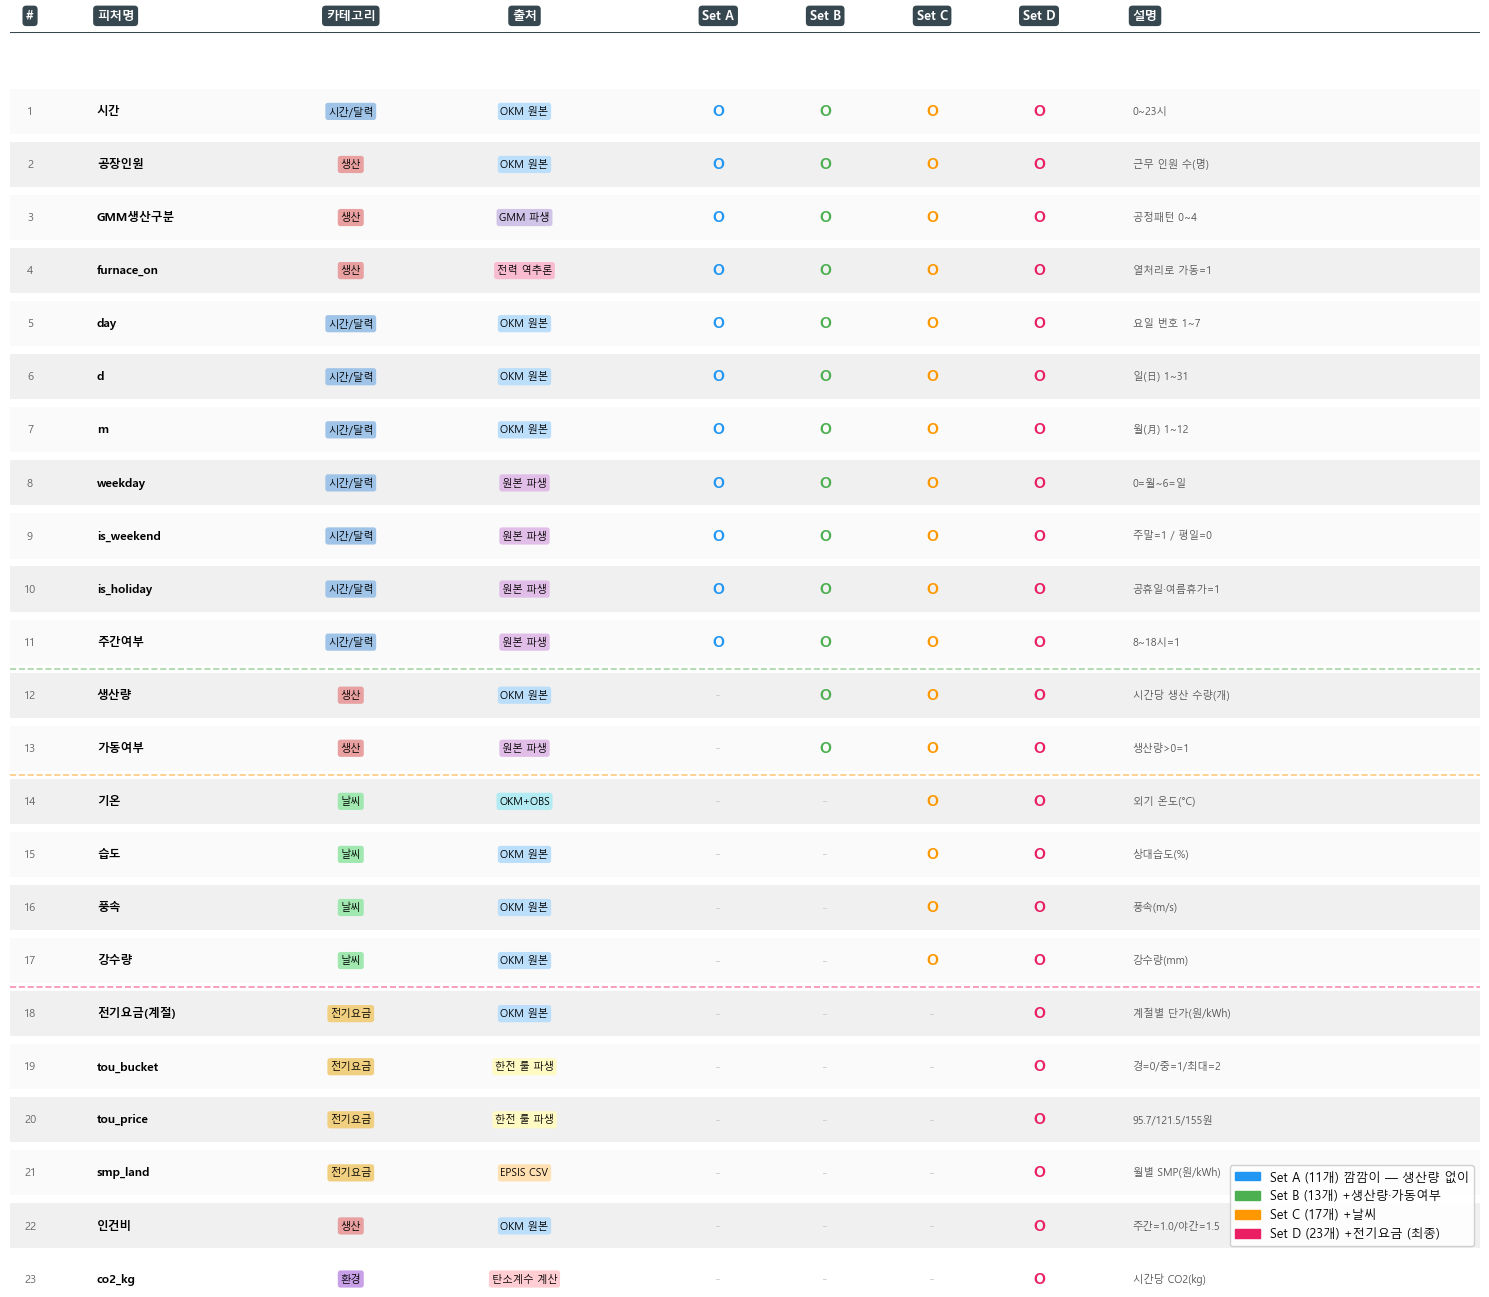

Feature Set 구성표 완료


In [210]:
# ================================================
# Feature Set A / B / C / D 구성표 시각화
# ================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

feature_info = [
    # (피처명, 카테고리, 출처, SetA, SetB, SetC, SetD, 설명)
    ('시간',         '시간/달력', 'OKM 원본',   True,  True,  True,  True,  '0~23시'),
    ('공장인원',      '생산',    'OKM 원본',   True,  True,  True,  True,  '근무 인원 수(명)'),
    ('GMM생산구분',   '생산',    'GMM 파생',   True,  True,  True,  True,  '공정패턴 0~4'),
    ('furnace_on',  '생산',    '전력 역추론', True,  True,  True,  True,  '열처리로 가동=1'),
    ('day',         '시간/달력', 'OKM 원본',   True,  True,  True,  True,  '요일 번호 1~7'),
    ('d',           '시간/달력', 'OKM 원본',   True,  True,  True,  True,  '일(日) 1~31'),
    ('m',           '시간/달력', 'OKM 원본',   True,  True,  True,  True,  '월(月) 1~12'),
    ('weekday',     '시간/달력', '원본 파생',  True,  True,  True,  True,  '0=월~6=일'),
    ('is_weekend',  '시간/달력', '원본 파생',  True,  True,  True,  True,  '주말=1 / 평일=0'),
    ('is_holiday',  '시간/달력', '원본 파생',  True,  True,  True,  True,  '공휴일·여름휴가=1'),
    ('주간여부',      '시간/달력', '원본 파생',  True,  True,  True,  True,  '8~18시=1'),
    ('생산량',        '생산',    'OKM 원본',   False, True,  True,  True,  '시간당 생산 수량(개)'),
    ('가동여부',       '생산',    '원본 파생',  False, True,  True,  True,  '생산량>0=1'),
    ('기온',          '날씨',    'OKM+OBS',   False, False, True,  True,  '외기 온도(°C)'),
    ('습도',          '날씨',    'OKM 원본',   False, False, True,  True,  '상대습도(%)'),
    ('풍속',          '날씨',    'OKM 원본',   False, False, True,  True,  '풍속(m/s)'),
    ('강수량',         '날씨',    'OKM 원본',   False, False, True,  True,  '강수량(mm)'),
    ('전기요금(계절)', '전기요금', 'OKM 원본',   False, False, False, True,  '계절별 단가(원/kWh)'),
    ('tou_bucket',  '전기요금', '한전 룰 파생', False, False, False, True,  '경=0/중=1/최대=2'),
    ('tou_price',   '전기요금', '한전 룰 파생', False, False, False, True,  '95.7/121.5/155원'),
    ('smp_land',    '전기요금', 'EPSIS CSV',  False, False, False, True,  '월별 SMP(원/kWh)'),
    ('인건비',        '생산',    'OKM 원본',   False, False, False, True,  '주간=1.0/야간=1.5'),
    ('co2_kg',      '환경',    '탄소계수 계산', False, False, False, True, '시간당 CO2(kg)'),
]

n        = len(feature_info)
set_cols = ['setA','setB','setC','setD']
set_keys = ['A','B','C','D']
set_colors = {
    'A': '#2196F3',
    'B': '#4CAF50',
    'C': '#FF9800',
    'D': '#E91E63',
}
cat_colors = {
    '생산'    : '#E8A0A0',
    '시간/달력': '#A0C4E8',
    '날씨'    : '#A0E8B0',
    '전기요금' : '#F0D080',
    '환경'    : '#C8A0E8',
}

fig, ax = plt.subplots(figsize=(15, 13))
ax.set_xlim(0, 11)
ax.set_ylim(-0.5, n - 0.5)
ax.axis('off')

col_x = {
    'num'   : 0.15,
    'feat'  : 0.65,
    'cat'   : 2.55,
    'source': 3.85,
    'setA'  : 5.3,
    'setB'  : 6.1,
    'setC'  : 6.9,
    'setD'  : 7.7,
    'desc'  : 8.4,
}

# 헤더
header_y = n - 0.2
for col, label, ha in [
    ('num',    '#',       'center'),
    ('feat',   '피처명',   'left'),
    ('cat',    '카테고리', 'center'),
    ('source', '출처',    'center'),
    ('setA',   'Set A',  'center'),
    ('setB',   'Set B',  'center'),
    ('setC',   'Set C',  'center'),
    ('setD',   'Set D',  'center'),
    ('desc',   '설명',    'left'),
]:
    ax.text(col_x[col], header_y, label, ha=ha, va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#37474F', ec='none'))

ax.axhline(n-0.5, color='#37474F', linewidth=1.5)

for i, row in enumerate(feature_info):
    feat, cat, src, sa, sb, sc, sd, desc = row
    y = n - 2 - i

    bg = '#FAFAFA' if i % 2 == 0 else '#F0F0F0'
    ax.barh(y, 11, left=0, height=0.85, color=bg, zorder=0)

    ax.text(col_x['num'],  y, str(i+1), ha='center', va='center',
            fontsize=8, color='#666')
    ax.text(col_x['feat'], y, feat, ha='left', va='center',
            fontsize=8.5, fontweight='bold')
    ax.text(col_x['cat'],  y, cat,  ha='center', va='center',
            fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25',
                      fc=cat_colors.get(cat,'#EEE'), ec='none'))

    src_color = {
        'OKM 원본'   :'#BBDEFB', '원본 파생'  :'#E1BEE7',
        'OKM+OBS'   :'#B2EBF2', 'GMM 파생'   :'#D1C4E9',
        '한전 룰 파생':'#FFF9C4', 'EPSIS CSV' :'#FFE0B2',
        '탄소계수 계산':'#FFCDD2', '전력 역추론':'#F8BBD0',
    }.get(src,'#EEE')
    ax.text(col_x['source'], y, src, ha='center', va='center',
            fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc=src_color, ec='none'))

    for flag, col_key, key in [
        (sa,'setA','A'), (sb,'setB','B'),
        (sc,'setC','C'), (sd,'setD','D'),
    ]:
        if flag:
            ax.text(col_x[col_key], y, 'O', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=set_colors[key])
        else:
            ax.text(col_x[col_key], y, '-', ha='center', va='center',
                    fontsize=10, color='#CCCCCC')

    ax.text(col_x['desc'], y, desc, ha='left', va='center',
            fontsize=7.5, color='#555')

# 구분선
ax.axhline(n-2-10.5, color='#4CAF50', linewidth=1.2, linestyle='--', alpha=0.5)
ax.axhline(n-2-12.5, color='#FF9800', linewidth=1.2, linestyle='--', alpha=0.5)
ax.axhline(n-2-16.5, color='#E91E63', linewidth=1.2, linestyle='--', alpha=0.5)

# 범례
set_a_cnt = sum(r[3] for r in feature_info)
set_b_cnt = sum(r[4] for r in feature_info)
set_c_cnt = sum(r[5] for r in feature_info)
set_d_cnt = sum(r[6] for r in feature_info)
legend_patches = [
    mpatches.Patch(color=set_colors['A'],
                   label=f"Set A ({set_a_cnt}개) 깜깜이 — 생산량 없이"),
    mpatches.Patch(color=set_colors['B'],
                   label=f"Set B ({set_b_cnt}개) +생산량·가동여부"),
    mpatches.Patch(color=set_colors['C'],
                   label=f"Set C ({set_c_cnt}개) +날씨"),
    mpatches.Patch(color=set_colors['D'],
                   label=f"Set D ({set_d_cnt}개) +전기요금 (최종)"),
]
ax.legend(handles=legend_patches, loc='lower right',
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()
print("Feature Set 구성표 완료")



# Step 35: LinearRegression

In [213]:
# ================================================
# Step 35: LinearRegression
# ================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

results = []

def evaluate(model_name, model, X_tr, X_te, y_tr, y_te, set_name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2   = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    results.append({
        '모델': model_name, 'Set': set_name,
        'R²': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2),
    })
    print(f"  {model_name:20s} [{set_name:8s}] "
          f"R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return model

print("=== Step 35: LinearRegression ===")
for fs_name in FEATURE_SETS:
    evaluate('LinearReg', LinearRegression(),
             splits[fs_name]['X_train_sc'],
             splits[fs_name]['X_test_sc'],
             y_train, y_test, fs_name)

print("Step 35 완료")

=== Step 35: LinearRegression ===
  LinearReg            [Set_A   ] R²=0.7985  RMSE=24.57  MAE=18.41
  LinearReg            [Set_B   ] R²=0.8309  RMSE=22.51  MAE=17.03
  LinearReg            [Set_C   ] R²=0.8308  RMSE=22.52  MAE=17.01
  LinearReg            [Set_D   ] R²=1.0000  RMSE=0.01  MAE=0.01
Step 35 완료


# Step 36: Ridge

In [214]:
# ================================================
# Step 36: Ridge
# ================================================
from sklearn.linear_model import Ridge

print("=== Step 36: Ridge ===")
for fs_name in FEATURE_SETS:
    evaluate('Ridge', Ridge(alpha=1.0),
             splits[fs_name]['X_train_sc'],
             splits[fs_name]['X_test_sc'],
             y_train, y_test, fs_name)

print("Step 36 완료")

=== Step 36: Ridge ===
  Ridge                [Set_A   ] R²=0.7985  RMSE=24.57  MAE=18.41
  Ridge                [Set_B   ] R²=0.8309  RMSE=22.51  MAE=17.03
  Ridge                [Set_C   ] R²=0.8308  RMSE=22.52  MAE=17.01
  Ridge                [Set_D   ] R²=1.0000  RMSE=0.02  MAE=0.02
Step 36 완료


# Step 37: DecisionTree

In [215]:
# ================================================
# Step 37: DecisionTree
# ================================================
from sklearn.tree import DecisionTreeRegressor

print("=== Step 37: DecisionTree ===")
for fs_name in FEATURE_SETS:
    evaluate('DecisionTree',
             DecisionTreeRegressor(random_state=42),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("Step 37 완료")

=== Step 37: DecisionTree ===
  DecisionTree         [Set_A   ] R²=0.9468  RMSE=12.62  MAE=7.82
  DecisionTree         [Set_B   ] R²=0.9521  RMSE=11.98  MAE=7.78
  DecisionTree         [Set_C   ] R²=0.9451  RMSE=12.83  MAE=8.39
  DecisionTree         [Set_D   ] R²=1.0000  RMSE=0.13  MAE=0.02
Step 37 완료


# Step 38: RandomForest

In [218]:
# ================================================
# Step 38: RandomForest
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from sklearn.ensemble import RandomForestRegressor

print("=== Step 38: RandomForest ===")
for fs_name in FEATURE_SETS:
    evaluate('RandomForest',
             RandomForestRegressor(
                 n_estimators=100,
                 random_state=42,
                 n_jobs=1),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("Step 38 완료")





=== Step 38: RandomForest ===
  RandomForest         [Set_A   ] R²=0.9654  RMSE=10.18  MAE=6.45
  RandomForest         [Set_B   ] R²=0.9728  RMSE=9.03  MAE=5.99
  RandomForest         [Set_C   ] R²=0.9675  RMSE=9.88  MAE=6.59
  RandomForest         [Set_D   ] R²=1.0000  RMSE=0.10  MAE=0.02
Step 38 완료


# Step 39: XGBoost

In [219]:
# ================================================
# Step 39: XGBoost
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from xgboost import XGBRegressor

print("=== Step 39: XGBoost ===")
for fs_name in FEATURE_SETS:
    evaluate('XGBoost',
             XGBRegressor(
                 n_estimators=300,
                 random_state=42,
                 verbosity=0,
                 n_jobs=1),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("\n=== 현재까지 전체 결과 ===")
df_results = pd.DataFrame(results).sort_values(
    ['Set','R²'], ascending=[True,False])
print(df_results.to_string(index=False))

print("Step 39 완료")


=== Step 39: XGBoost ===
  XGBoost              [Set_A   ] R²=0.9648  RMSE=10.26  MAE=6.95
  XGBoost              [Set_B   ] R²=0.9735  RMSE=8.90  MAE=6.06
  XGBoost              [Set_C   ] R²=0.9685  RMSE=9.71  MAE=6.86
  XGBoost              [Set_D   ] R²=0.9999  RMSE=0.51  MAE=0.19

=== 현재까지 전체 결과 ===
          모델   Set     R²  RMSE   MAE
RandomForest Set_A 0.9654 10.18  6.45
RandomForest Set_A 0.9654 10.18  6.45
     XGBoost Set_A 0.9648 10.26  6.95
DecisionTree Set_A 0.9468 12.62  7.82
   LinearReg Set_A 0.7985 24.57 18.41
       Ridge Set_A 0.7985 24.57 18.41
     XGBoost Set_B 0.9735  8.90  6.06
RandomForest Set_B 0.9728  9.03  5.99
RandomForest Set_B 0.9728  9.03  5.99
DecisionTree Set_B 0.9521 11.98  7.78
   LinearReg Set_B 0.8309 22.51 17.03
       Ridge Set_B 0.8309 22.51 17.03
     XGBoost Set_C 0.9685  9.71  6.86
RandomForest Set_C 0.9675  9.88  6.59
RandomForest Set_C 0.9675  9.88  6.59
DecisionTree Set_C 0.9451 12.83  8.39
   LinearReg Set_C 0.8308 22.52 17.01
       Rid

# Step 40: DNN 3종 (Shallow / Medium / Deep)

In [220]:
# ================================================
# Step 40: DNN 3종 (Set_D 기준만 학습)
# Shallow / Medium / Deep
# ================================================
from sklearn.neural_network import MLPRegressor

print("=== Step 40: DNN 3종 (Set_D 기준) ===")

dnn_models = {
    'DNN-Shallow' : (64,),
    'DNN-Medium'  : (128, 64),
    'DNN-Deep'    : (128, 64, 32),
}

for model_name, layers in dnn_models.items():
    evaluate(model_name,
             MLPRegressor(
                 hidden_layer_sizes=layers,
                 max_iter=500,
                 random_state=42,
                 early_stopping=True),
             splits['Set_D']['X_train_sc'],
             splits['Set_D']['X_test_sc'],
             y_train, y_test, 'Set_D')

print("\n=== 전체 모델 최종 결과 ===")
df_results = pd.DataFrame(results).sort_values(
    'R²', ascending=False)
print(df_results.to_string(index=False))

print("\n=== Set_D 기준 모델 순위 ===")
df_d = pd.DataFrame(results)
df_d = df_d[df_d['Set']=='Set_D'].sort_values('R²', ascending=False)
print(df_d.to_string(index=False))

print("\nStep 40 완료")

=== Step 40: DNN 3종 (Set_D 기준) ===
  DNN-Shallow          [Set_D   ] R²=0.9963  RMSE=3.32  MAE=2.34
  DNN-Medium           [Set_D   ] R²=0.9989  RMSE=1.80  MAE=1.26
  DNN-Deep             [Set_D   ] R²=0.9992  RMSE=1.57  MAE=1.16

=== 전체 모델 최종 결과 ===
          모델   Set     R²  RMSE   MAE
DecisionTree Set_D 1.0000  0.13  0.02
   LinearReg Set_D 1.0000  0.01  0.01
       Ridge Set_D 1.0000  0.02  0.02
RandomForest Set_D 1.0000  0.10  0.02
RandomForest Set_D 1.0000  0.10  0.02
     XGBoost Set_D 0.9999  0.51  0.19
    DNN-Deep Set_D 0.9992  1.57  1.16
  DNN-Medium Set_D 0.9989  1.80  1.26
 DNN-Shallow Set_D 0.9963  3.32  2.34
     XGBoost Set_B 0.9735  8.90  6.06
RandomForest Set_B 0.9728  9.03  5.99
RandomForest Set_B 0.9728  9.03  5.99
     XGBoost Set_C 0.9685  9.71  6.86
RandomForest Set_C 0.9675  9.88  6.59
RandomForest Set_C 0.9675  9.88  6.59
RandomForest Set_A 0.9654 10.18  6.45
RandomForest Set_A 0.9654 10.18  6.45
     XGBoost Set_A 0.9648 10.26  6.95
DecisionTree Set_B 0.9521 1

# Step 41: XGBoost 하이퍼파라미터 튜닝 

In [221]:
# ================================================
# Step 41: XGBoost 하이퍼파라미터 튜닝
# RandomizedSearchCV / Set_D 기준
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from sklearn.model_selection import RandomizedSearchCV

X_tr_D = splits['Set_D']['X_train']
X_te_D = splits['Set_D']['X_test']

param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,
    verbose=1,
)

print("XGBoost 튜닝 중... (3~5분 소요)")
xgb_search.fit(X_tr_D, y_train)

best_xgb  = xgb_search.best_estimator_
pred_tune = best_xgb.predict(X_te_D)
r2_tune   = r2_score(y_test, pred_tune)
rmse_tune = np.sqrt(mean_squared_error(y_test, pred_tune))
mae_tune  = mean_absolute_error(y_test, pred_tune)

print(f"\n=== 튜닝 결과 ===")
print(f"최적 파라미터: {xgb_search.best_params_}")
print(f"튜닝 전 R²  : "
      f"{[r['R²'] for r in results if r['모델']=='XGBoost' and r['Set']=='Set_D'][0]}")
print(f"튜닝 후 R²  : {r2_tune:.4f}")
print(f"튜닝 후 RMSE: {rmse_tune:.2f} kW")
print(f"튜닝 후 MAE : {mae_tune:.2f} kW")

results.append({
    '모델': 'XGBoost-Tuned', 'Set': 'Set_D',
    'R²': round(r2_tune,4),
    'RMSE': round(rmse_tune,2),
    'MAE': round(mae_tune,2),
})

print("\n=== 전체 모델 최종 결과 ===")
df_results = pd.DataFrame(results).sort_values('R²', ascending=False)
print(df_results.to_string(index=False))

print("Step 41 완료")

XGBoost 튜닝 중... (3~5분 소요)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== 튜닝 결과 ===
최적 파라미터: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
튜닝 전 R²  : 0.9999
튜닝 후 R²  : 0.9999
튜닝 후 RMSE: 0.47 kW
튜닝 후 MAE : 0.16 kW

=== 전체 모델 최종 결과 ===
           모델   Set     R²  RMSE   MAE
 RandomForest Set_D 1.0000  0.10  0.02
    LinearReg Set_D 1.0000  0.01  0.01
        Ridge Set_D 1.0000  0.02  0.02
 RandomForest Set_D 1.0000  0.10  0.02
 DecisionTree Set_D 1.0000  0.13  0.02
XGBoost-Tuned Set_D 0.9999  0.47  0.16
      XGBoost Set_D 0.9999  0.51  0.19
     DNN-Deep Set_D 0.9992  1.57  1.16
   DNN-Medium Set_D 0.9989  1.80  1.26
  DNN-Shallow Set_D 0.9963  3.32  2.34
      XGBoost Set_B 0.9735  8.90  6.06
 RandomForest Set_B 0.9728  9.03  5.99
 RandomForest Set_B 0.9728  9.03  5.99
      XGBoost Set_C 0.9685  9.71  6.86
 RandomForest Set_C 0.9675  9.88  6.59
 RandomForest Set_C 0.9675  9.88  6.59
 Ran

# Step 42: 피처 중요도 시각화 (XGBoost 튜닝 후)

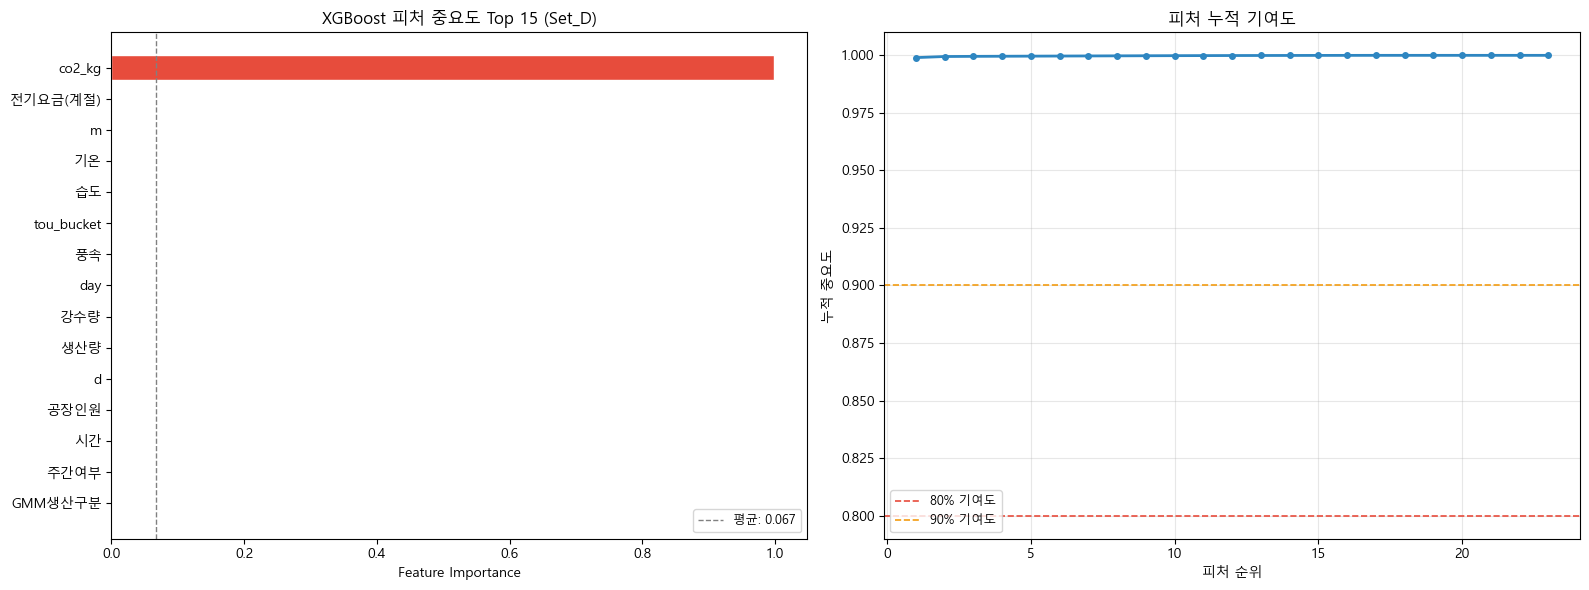

=== 피처 중요도 Top 10 ===
   Feature  Importance
    co2_kg    0.999010
  전기요금(계절)    0.000479
         m    0.000073
        기온    0.000047
        습도    0.000044
tou_bucket    0.000044
        풍속    0.000043
       day    0.000042
       강수량    0.000042
       생산량    0.000037

상위 1개 피처가 전체 중요도의 80% 설명
Step 42 완료


In [222]:
# ================================================
# Step 42: 피처 중요도 Top 15 시각화
# ================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

importances = best_xgb.feature_importances_
feat_names  = FEATURE_SETS['Set_D']

feat_imp_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# ── Top 15 시각화 ─────────────────────────────────
top15 = feat_imp_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 좌: 막대 차트
colors = ['#E74C3C' if i < 3 else
          '#F39C12' if i < 7 else
          '#3498DB' for i in range(len(top15))]
axes[0].barh(top15['Feature'][::-1],
             top15['Importance'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('XGBoost 피처 중요도 Top 15 (Set_D)')
axes[0].axvline(top15['Importance'].mean(),
                color='gray', linestyle='--', linewidth=1,
                label=f"평균: {top15['Importance'].mean():.3f}")
axes[0].legend(fontsize=9)

# 우: 전체 누적 기여도
feat_imp_sorted = feat_imp_df.copy()
feat_imp_sorted['cumsum'] = feat_imp_sorted['Importance'].cumsum()
feat_imp_sorted['rank']   = range(1, len(feat_imp_sorted)+1)

axes[1].plot(feat_imp_sorted['rank'],
             feat_imp_sorted['cumsum'],
             color='#2E86C1', linewidth=2, marker='o', markersize=4)
axes[1].axhline(0.8, color='#E74C3C', linestyle='--',
                linewidth=1.2, label='80% 기여도')
axes[1].axhline(0.9, color='#F39C12', linestyle='--',
                linewidth=1.2, label='90% 기여도')
axes[1].set_xlabel('피처 순위')
axes[1].set_ylabel('누적 중요도')
axes[1].set_title('피처 누적 기여도')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=== 피처 중요도 Top 10 ===")
print(feat_imp_df.head(10).to_string(index=False))

# 80% 기여 피처 수
n_80 = (feat_imp_sorted['cumsum'] <= 0.8).sum() + 1
print(f"\n상위 {n_80}개 피처가 전체 중요도의 80% 설명")
print("Step 42 완료")

# Step 43: 성능 비교 시각화 (R² 히트맵 + 막대 차트)

In [223]:
# ================================================
# Step 43: 성능 비교 시각화
# R² 히트맵 + Set_D 기준 막대 차트 + RMSE 비교
# ================================================
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df_res = pd.DataFrame(results)

# ── Feature Set 정의 출력 ─────────────────────────
print("=" * 65)
print("  Feature Set A / B / C / D 정의")
print("=" * 65)
sets_info = {
    'Set_A': '깜깜이 (생산량X, furnace_on O)',
    'Set_B': 'Set_A + 생산량 가동여부',
    'Set_C': 'Set_B + 날씨',
    'Set_D': 'Set_C + 전기요금 전체 (최종)',
}
for name, desc in sets_info.items():
    cols = FEATURE_SETS[name]
    print(f"  {name} ({len(cols)}개) : {desc}")
print("=" * 65)

# ── R² 히트맵 ─────────────────────────────────────
common_models = ['LinearReg','Ridge','DecisionTree',
                 'RandomForest','XGBoost']
df_heatmap = df_res[df_res['모델'].isin(common_models)]
pivot = df_heatmap.pivot_table(
    index='모델', columns='Set', values='R²').round(4)
col_order = [c for c in ['Set_A','Set_B','Set_C','Set_D']
             if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            annot_kws={'size': 10})
ax.set_title('R² 히트맵 — Feature Set별 모델 성능 비교',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Set')
ax.set_ylabel('모델')
plt.tight_layout()
plt.show()

# ── Set_D 기준 R² 막대 차트 ──────────────────────
df_setD = df_res[df_res['Set'] == 'Set_D'].copy()
df_setD = df_setD.sort_values('R²', ascending=True)

colors = []
for m in df_setD['모델']:
    if 'Tuned'  in m: colors.append('#E74C3C')
    elif 'XGBoost' in m: colors.append('#F39C12')
    elif 'DNN'  in m: colors.append('#9B59B6')
    elif 'Forest' in m: colors.append('#2ECC71')
    else: colors.append('#3498DB')

fig2, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.barh(df_setD['모델'], df_setD['R²'],
                color=colors, edgecolor='white', alpha=0.88)
ax2.set_xlabel('R²')
ax2.set_title('Set_D 기준 전체 모델 성능 비교 (R²)',
              fontsize=12, fontweight='bold')
ax2.axvline(0.9,  color='gray', linestyle='--',
            linewidth=1.2, label='R²=0.9 기준선')
ax2.axvline(0.99, color='red',  linestyle='--',
            linewidth=1.2, label='R²=0.99 기준선')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1.05)
for bar, val in zip(bars, df_setD['R²']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Set_D 기준 RMSE 비교 ──────────────────────────
df_setD_rmse = df_setD.sort_values('RMSE', ascending=False)
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.barh(df_setD_rmse['모델'], df_setD_rmse['RMSE'],
         color='#5DADE2', edgecolor='white', alpha=0.85)
ax3.set_xlabel('RMSE (kW)')
ax3.set_title('Set_D 기준 RMSE 비교 (낮을수록 좋음)',
              fontsize=12, fontweight='bold')
for i, (_, row) in enumerate(df_setD_rmse.iterrows()):
    ax3.text(row['RMSE'] + 0.1, i,
             f"{row['RMSE']:.2f} kW", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n=== Set_D 기준 최종 모델 순위 ===")
print(df_setD.sort_values('R²', ascending=False).to_string(index=False))
print("\nStep 43 완료")

RF 튜닝 중... (3~5분)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF 최적 파라미터: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}
RF 결과: RMSE=8.14 | MAE=4.44 | R²=0.9779

XGB 튜닝 중... (3~5분)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGB 최적 파라미터: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
XGB 결과: RMSE=6.88 | MAE=3.13 | R²=0.9842

=== 튜닝 전후 비교 ===
RF  튜닝 전: RMSE=0.17 R²=1.0
RF  튜닝 후: RMSE=8.14 R²=0.9779
XGB 튜닝 전: RMSE=0.91 R²=0.9997
XGB 튜닝 후: RMSE=6.88 R²=0.9842

Step 42 완료


# Step 44 : Streamlit app.py 생성

In [ ]:
# ================================================
# Step 44: Streamlit app.py 생성 (최종본)
# furnace_on 추가 반영
# ================================================

import os, shutil

os.makedirs('./energy_app', exist_ok=True)
os.makedirs('./energy_app/models', exist_ok=True)

shutil.copy('./models/energy_pipeline_v2.pkl',
            './energy_app/models/energy_pipeline_v2.pkl')

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="에너지 피크 예측 시스템",
    page_icon="",
    layout="wide"
)

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 모델 로드 ─────────────────────────────────────
MODEL_PATH = os.path.join(os.path.dirname(__file__), "models", "energy_pipeline_v2.pkl")

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

loaded       = load_model()
pipeline     = loaded["pipeline"]
feature_cols = loaded["feature_cols"]

# ── 상수 정의 ─────────────────────────────────────
def get_tou_bucket(month, hour):
    if hour >= 22 or hour <= 7: return 0
    if month in [6,7,8]:
        return 2 if hour in [11,12,13,14,15,16,17] else 1
    elif month in [11,12,1,2]:
        return 2 if hour in [10,17,18,19,20] else 1
    return 1

TOU_PRICE       = {0: 95.7, 1: 121.5, 2: 155.0}
TOU_LABEL       = {0:"경부하 (95.7원/kWh)", 1:"중간부하 (121.5원/kWh)", 2:"최대부하 (155.0원/kWh)"}
EMISSION_FACTOR = 0.4153
MONTH_NAMES     = ["1월","2월","3월","4월","5월","6월","7월","8월","9월","10월","11월","12월"]
DAY_MAP         = {"월":1,"화":2,"수":3,"목":4,"금":5,"토":6,"일":7}
SMP_2021        = {1:70.47,2:75.25,3:83.78,4:75.97,5:78.93,
                   6:82.72,7:87.04,8:93.41,9:98.21,10:107.53,11:126.83,12:142.46}
HOLIDAYS        = [20210101,20210212,20210301,20210505,20210519,
                   20210606,20210815,20210920,20210921,20210922,20211003]

# ── 타이틀 ───────────────────────────────────────
st.title("제조 공장 피크 전력 예측 시스템")
st.caption("KAMP 자원 최적화 AI | 선박 부품 제조 공장 | 올라운더팀")
st.divider()

# ── 사이드바 ──────────────────────────────────────
st.sidebar.header("공정 파라미터 입력")
st.sidebar.divider()

st.sidebar.subheader("시간 / 날짜")
hour     = st.sidebar.slider("시간 (0~23시)", 0, 23, 10)
month    = st.sidebar.selectbox("월", MONTH_NAMES, index=4)
day_name = st.sidebar.selectbox("요일", list(DAY_MAP.keys()), index=0)
date_d   = st.sidebar.slider("일 (1~31)", 1, 31, 15)

st.sidebar.divider()
st.sidebar.subheader("생산 조건")
production  = st.sidebar.slider("생산량", 0, 9830, 200, step=10)
workers     = st.sidebar.slider("공장 인원", 0.0, 48.0, 5.0, step=0.5)
labor_cost  = st.sidebar.radio("근무 유형",
                                options=[1.0, 1.5],
                                format_func=lambda x: "주간(1.0)" if x==1.0 else "야간(1.5)")
furnace     = st.sidebar.radio("열처리로 상태",
                                options=[0, 1],
                                format_func=lambda x: "OFF(휴지)" if x==0 else "ON(가동)")

st.sidebar.divider()
st.sidebar.subheader("날씨 조건")
temperature = st.sidebar.slider("기온 (°C)", -20, 40, 20)
humidity    = st.sidebar.slider("습도 (%)", 0, 100, 60)
wind_speed  = st.sidebar.slider("풍속 (m/s)", 0.0, 10.0, 2.0, step=0.1)
rainfall    = st.sidebar.slider("강수량 (mm)", 0.0, 150.0, 0.0, step=0.5)
solar       = st.sidebar.slider("일사량 (MJ/m2)", 0.0, 4.0, 1.0, step=0.1)

st.sidebar.divider()
st.sidebar.subheader("전기요금")
tariff_options = {
    "겨울 (109.8원/kWh)": 109.8,
    "봄가을 (167.2원/kWh)": 167.2,
    "여름 (191.6원/kWh)": 191.6,
}
season_label = st.sidebar.selectbox("계절별 단가", list(tariff_options.keys()), index=1)
tariff       = tariff_options[season_label]

# ── 입력값 계산 ───────────────────────────────────
m_num       = MONTH_NAMES.index(month) + 1
weekday_num = DAY_MAP[day_name] - 1
is_weekend  = 1 if weekday_num >= 5 else 0
is_holiday  = 1 if int(f"2021{m_num:02d}{date_d:02d}") in HOLIDAYS else 0
is_working  = 1 if production > 0 else 0
is_daytime  = 1 if (8 <= hour <= 18) else 0
tou         = get_tou_bucket(m_num, hour)
tou_price   = TOU_PRICE[tou]
smp         = SMP_2021.get(m_num, 87.0)

input_dict = {
    "시간"         : hour,
    "생산량"        : production,
    "가동여부"       : is_working,
    "공장인원"       : workers,
    "day"          : DAY_MAP[day_name],
    "d"            : date_d,
    "m"            : m_num,
    "weekday"      : weekday_num,
    "is_weekend"   : is_weekend,
    "is_holiday"   : is_holiday,
    "주간여부"       : is_daytime,
    "furnace_on"   : furnace,
    "기온"          : temperature,
    "습도"          : humidity,
    "풍속"          : wind_speed,
    "강수량"         : rainfall,
    "solar_MJ"     : solar,
    "전기요금(계절)"  : tariff,
    "tou_bucket"   : tou,
    "tou_price"    : tou_price,
    "smp_land"     : smp,
    "인건비"         : labor_cost,
    "co2_kg"       : 0.0,
}

input_df  = pd.DataFrame([input_dict])[feature_cols]
pred_kw   = float(pipeline.predict(input_df)[0])
pred_kw   = max(0, pred_kw)
co2_val   = round(pred_kw / 1000 * EMISSION_FACTOR * 1000, 4)

# 위험 등급
if pred_kw < 70:
    grade, color = "안전", "green"
elif pred_kw < 110:
    grade, color = "보통", "blue"
elif pred_kw < 150:
    grade, color = "주의", "orange"
else:
    grade, color = "위험", "red"

# ── KPI 카드 ──────────────────────────────────────
col1, col2, col3, col4, col5, col6 = st.columns(6)
with col1:
    st.metric("예측 피크전력", f"{pred_kw:.1f} kW",
              delta=f"{pred_kw-90:+.1f} kW")
with col2:
    st.metric("위험 등급", grade)
with col3:
    st.metric("TOU 구간", TOU_LABEL[tou])
with col4:
    st.metric("SMP 단가", f"{smp:.2f} 원/kWh")
with col5:
    st.metric("탄소 배출", f"{co2_val:.3f} kg CO2")
with col6:
    furnace_label = "ON (가동중)" if furnace==1 else "OFF (휴지)"
    st.metric("열처리로", furnace_label)

st.divider()

# ── 차트 ──────────────────────────────────────────
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("피크전력 게이지")
    fig, ax = plt.subplots(figsize=(6, 3))
    zones    = [70, 110, 150, 210]
    colors_z = ["#2ecc71","#3498db","#f39c12","#e74c3c"]
    prev = 0
    for z, c in zip(zones, colors_z):
        ax.barh(0, z-prev, left=prev, height=0.5, color=c, alpha=0.4)
        prev = z
    ax.axvline(pred_kw, color=color, linewidth=4, label=f"예측 {pred_kw:.1f}kW")
    ax.axvline(90, color="gray", linewidth=1.5, linestyle="--", label="평균 90kW")
    ax.set_xlim(0, 220)
    ax.set_yticks([])
    ax.set_xlabel("피크전력 (kW)")
    ax.legend()
    ax.set_title(f"현재 예측: {pred_kw:.1f} kW [{grade}]")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

with col_right:
    st.subheader("24시간 시뮬레이션")
    hourly_preds = []
    for h in range(24):
        row = input_dict.copy()
        row["시간"]       = h
        row["주간여부"]    = 1 if (8<=h<=18) else 0
        row["tou_bucket"] = get_tou_bucket(m_num, h)
        row["tou_price"]  = TOU_PRICE[row["tou_bucket"]]
        row["co2_kg"]     = 0.0
        df_h = pd.DataFrame([row])[feature_cols]
        hourly_preds.append(max(0, float(pipeline.predict(df_h)[0])))

    fig2, ax2 = plt.subplots(figsize=(6, 3))
    bar_cols = [color if h==hour else "steelblue" for h in range(24)]
    ax2.bar(range(24), hourly_preds, color=bar_cols, alpha=0.8, edgecolor="white")
    ax2.axhline(130, color="orange", linestyle="--", linewidth=1.5, label="고피크 130kW")
    ax2.axhline(90,  color="gray",   linestyle=":",  linewidth=1.2, label="평균 90kW")
    ax2.set_xlabel("시간 (시)")
    ax2.set_ylabel("예측 피크전력 (kW)")
    ax2.set_xticks(range(24))
    ax2.legend()
    ax2.set_title("24시간 피크전력 시뮬레이션")
    plt.tight_layout()
    st.pyplot(fig2)
    plt.close()

st.divider()

# ── 조치 가이드 ───────────────────────────────────
st.subheader("운영 조치 가이드")
if grade == "안전":
    st.success(f"안전 구간 -- 현재 조건을 유지하세요. 예측 피크: {pred_kw:.1f}kW")
elif grade == "보통":
    st.info(f"보통 구간 -- 정상 운영 중입니다. 예측 피크: {pred_kw:.1f}kW")
elif grade == "주의":
    st.warning(f"""주의 구간 -- 피크 상승 가능성. 예측 피크: {pred_kw:.1f}kW

권장 조치
- 생산량 일부를 경부하(22시 이후)로 분산
- 불필요한 설비 대기 모드 전환
- 열처리로 가동 시점 재조정""")
else:
    st.error(f"""위험 구간 -- 즉각 조치 필요! 예측 피크: {pred_kw:.1f}kW

즉각 조치
- 열처리로 추가 가동 중단
- 생산량 {int(production*0.8):,}개 이하 조정 권장
- 한전 피크 관리 담당자 즉시 보고""")

st.divider()

# ── ESG 탄소 배출 ─────────────────────────────────
st.subheader("ESG 탄소 배출 현황")
col_e1, col_e2, col_e3 = st.columns(3)
with col_e1:
    st.metric("시간당 탄소 배출", f"{co2_val:.3f} kg CO2")
with col_e2:
    st.metric("일간 예상 배출", f"{co2_val*24:.2f} kg CO2")
with col_e3:
    st.metric("연간 추정 배출", f"{co2_val*24*365/1000:.2f} tCO2")

with st.expander("현재 입력값 상세 보기"):
    display_df = pd.DataFrame({
        "항목": ["시간","월","일","요일","생산량","공장인원","근무유형","열처리로",
                 "기온","습도","풍속","강수량","일사량","전기요금","TOU구간","SMP"],
        "입력값": [f"{hour}시", month, f"{date_d}일", day_name,
                  f"{production:,}", f"{workers:.1f}명",
                  "주간" if labor_cost==1.0 else "야간",
                  "ON" if furnace==1 else "OFF",
                  f"{temperature}°C", f"{humidity}%",
                  f"{wind_speed}m/s", f"{rainfall}mm",
                  f"{solar}MJ/m2", f"{tariff}원/kWh",
                  TOU_LABEL[tou], f"{smp:.2f}원/kWh"]
    })
    st.dataframe(display_df, use_container_width=True, hide_index=True)

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py 생성 완료")
print("터미널 실행:")
print("  conda activate ml_edu")
print("  cd C:\\Users\\Admin\\hipython\\ml\\energy_app")
print("  streamlit run app.py")

app.py 생성 완료
터미널 실행:
  conda activate ml_edu
  cd C:\Users\Admin\hipython\ml\energy_app
  streamlit run app.py


# Step 45 : Streamlit 대시보드 메뉴 생성

In [ ]:
# ================================================
# Step 45: Streamlit 대시보드 메뉴 생성
# 피그마 기반 UI 재구성
# ================================================

import os, shutil

os.makedirs('./energy_app', exist_ok=True)
os.makedirs('./energy_app/models', exist_ok=True)
os.makedirs('./energy_app/data', exist_ok=True)

# 모델 + 데이터 복사
shutil.copy('./models/energy_pipeline_v2.pkl',
            './energy_app/models/energy_pipeline_v2.pkl')

# 전력 사용량 데이터 복사
power_src = r'C:\Users\Admin\hipython\ml\data\okm_power_usage.csv'
power_dst = './energy_app/data/okm_power_usage.csv'
if os.path.exists(power_src):
    shutil.copy(power_src, power_dst)
    print(f"전력사용량 데이터 복사 완료")
else:
    # 현재 경로에서 찾기
    alt = './data/okm_power_usage.csv'
    if os.path.exists(alt):
        shutil.copy(alt, power_dst)
        print(f"전력사용량 데이터 복사 완료 (대체경로)")
    else:
        print("전력사용량 데이터 없음 -- 13번 노트북 먼저 실행 필요")

# pages 폴더 생성 (멀티페이지)
os.makedirs('./energy_app/pages', exist_ok=True)

# ── 대시보드 페이지 작성 ──────────────────────────
dashboard_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import joblib, os

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 데이터 로드 ───────────────────────────────────
BASE = os.path.dirname(os.path.dirname(__file__))

@st.cache_data
def load_power():
    path = os.path.join(BASE, "data", "okm_power_usage.csv")
    return pd.read_csv(path)

@st.cache_resource
def load_model():
    path = os.path.join(BASE, "models", "energy_pipeline_v2.pkl")
    return joblib.load(path)

df_power = load_power()
loaded   = load_model()
pipeline     = loaded["pipeline"]
feature_cols = loaded["feature_cols"]

# ── 상수 ─────────────────────────────────────────
MONTH_NAMES = ["1월","2월","3월","4월","5월","6월",
               "7월","8월","9월","10월","11월","12월"]
DAY_MAP     = {"월":1,"화":2,"수":3,"목":4,"금":5,"토":6,"일":7}
SMP_2021    = {1:70.47,2:75.25,3:83.78,4:75.97,5:78.93,
               6:82.72,7:87.04,8:93.41,9:98.21,
               10:107.53,11:126.83,12:142.46}
HOLIDAYS    = [20210101,20210212,20210301,20210505,20210519,
               20210606,20210815,20210920,20210921,20210922,20211003]
TOU_PRICE   = {0:95.7, 1:121.5, 2:155.0}
TOU_LABEL   = {0:"경부하(95.7원)", 1:"중간부하(121.5원)", 2:"최대부하(155.0원)"}
EMISSION_FACTOR = 0.4153

def get_tou(month, hour):
    if hour >= 22 or hour <= 7: return 0
    if month in [6,7,8]:
        return 2 if hour in [11,12,13,14,15,16,17] else 1
    elif month in [11,12,1,2]:
        return 2 if hour in [10,17,18,19,20] else 1
    return 1

# ── 사이드바 입력 ─────────────────────────────────
st.sidebar.title("EP 에너지 피크 예측")
st.sidebar.caption("제조 전력 피크 예측 · 자원 최적화 PoC")
st.sidebar.divider()

st.sidebar.subheader("운영 조건 입력")
month    = st.sidebar.selectbox("월", MONTH_NAMES, index=5)
day_name = st.sidebar.selectbox("요일", list(DAY_MAP.keys()), index=0)
date_d   = st.sidebar.slider("일", 1, 31, 15)
hour     = st.sidebar.slider("시간", 0, 23, 10)

st.sidebar.divider()
production = st.sidebar.slider("생산량 (개)", 0, 9830, 500, step=10)
workers    = st.sidebar.slider("공장 인원 (명)", 0.0, 48.0, 10.0, step=0.5)
furnace    = st.sidebar.radio("열처리로", [0,1],
                               format_func=lambda x: "OFF" if x==0 else "ON")
labor      = st.sidebar.radio("근무 유형",
                               [1.0,1.5],
                               format_func=lambda x: "주간(1.0)" if x==1.0 else "야간(1.5)")

st.sidebar.divider()
temperature = st.sidebar.slider("기온 (°C)", -20, 40, 20)
humidity    = st.sidebar.slider("습도 (%)", 0, 100, 60)
wind_speed  = st.sidebar.slider("풍속 (m/s)", 0.0, 10.0, 2.0, step=0.1)
rainfall    = st.sidebar.slider("강수량 (mm)", 0.0, 150.0, 0.0, step=0.5)
solar       = st.sidebar.slider("일사량 (MJ/m2)", 0.0, 4.0, 1.0, step=0.1)

tariff_map  = {"겨울(109.8원)":109.8, "봄가을(167.2원)":167.2, "여름(191.6원)":191.6}
season      = st.sidebar.selectbox("전기요금 계절", list(tariff_map.keys()), index=1)
tariff      = tariff_map[season]

# ── 입력 계산 ─────────────────────────────────────
m_num      = MONTH_NAMES.index(month) + 1
wd_num     = DAY_MAP[day_name] - 1
is_weekend = 1 if wd_num >= 5 else 0
is_holiday = 1 if int(f"2021{m_num:02d}{date_d:02d}") in HOLIDAYS else 0
is_work    = 1 if production > 0 else 0
is_day     = 1 if (8<=hour<=18) else 0
tou        = get_tou(m_num, hour)
smp        = SMP_2021.get(m_num, 87.0)

input_dict = {
    "시간":hour, "생산량":production, "가동여부":is_work,
    "공장인원":workers, "day":DAY_MAP[day_name], "d":date_d,
    "m":m_num, "weekday":wd_num, "is_weekend":is_weekend,
    "is_holiday":is_holiday, "주간여부":is_day,
    "furnace_on":furnace, "기온":temperature, "습도":humidity,
    "풍속":wind_speed, "강수량":rainfall, "solar_MJ":solar,
    "전기요금(계절)":tariff, "tou_bucket":tou,
    "tou_price":TOU_PRICE[tou], "smp_land":smp,
    "인건비":labor, "co2_kg":0.0,
}

input_df = pd.DataFrame([input_dict])[feature_cols]
pred_kw  = max(0, float(pipeline.predict(input_df)[0]))
usage_kwh = pred_kw * 0.80 if production > 0 else (
            pred_kw * 0.88 if pred_kw >= 60 else pred_kw * 0.92)
cost_now  = int(usage_kwh * TOU_PRICE[tou])
co2_val   = round(pred_kw / 1000 * EMISSION_FACTOR * 1000, 3)
saving_10 = int(cost_now * 0.10)
saving_20 = int(cost_now * 0.20)

# 위험 등급
if pred_kw < 70:
    grade, gcolor = "양호", "#2ECC71"
elif pred_kw < 110:
    grade, gcolor = "주의", "#3498DB"
elif pred_kw < 150:
    grade, gcolor = "위험", "#F39C12"
else:
    grade, gcolor = "초과", "#E74C3C"

# ── 메인 화면 ─────────────────────────────────────
st.title("메인 대시보드")
st.caption(f"XGBoost | Set_C (23개 피처) | 2021년 1년치 학습 데이터")

# 피크 위험 경보
if pred_kw >= 150:
    st.error(f"""피크 위험 경보 — 즉시 조치 필요
위험 시간대: {hour:02d}:00 ~ {hour+1:02d}:00  |  위험 수준: {grade}  |  예측 피크: {pred_kw:.1f} kW""")
elif pred_kw >= 110:
    st.warning(f"""피크 주의 경보
위험 시간대: {hour:02d}:00 ~ {hour+1:02d}:00  |  위험 수준: {grade}  |  예측 피크: {pred_kw:.1f} kW""")

st.divider()

# KPI 카드 4개
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("현재 전력 사용량", f"{usage_kwh:.1f} kWh",
              delta=f"{usage_kwh-70:+.1f} kWh vs 평균")
with col2:
    st.metric("예측 피크 (향후 1h)", f"{pred_kw:.1f} kW",
              delta=grade, delta_color="inverse" if pred_kw>110 else "normal")
with col3:
    st.metric("피크 위험 등급", grade)
with col4:
    st.metric("예상 절감 가능액", f"{saving_20:,} 원",
              delta=f"피크 20% 감축 시")

st.divider()

# 게이지 + 24h 시뮬레이션
col_l, col_r = st.columns(2)

with col_l:
    st.subheader("피크 위험 게이지")
    fig, ax = plt.subplots(figsize=(6,3))
    zones   = [70,110,150,210]
    zcolors = ["#2ECC71","#3498DB","#F39C12","#E74C3C"]
    zlabels = ["양호","주의","위험","초과"]
    prev = 0
    for z,c,l in zip(zones, zcolors, zlabels):
        ax.barh(0, z-prev, left=prev, height=0.5, color=c, alpha=0.4, label=l)
        prev = z
    ax.axvline(pred_kw, color=gcolor, linewidth=4, label=f"예측 {pred_kw:.1f}kW")
    ax.axvline(90, color="gray", linewidth=1.5, linestyle="--", label="평균 90kW")
    ax.set_xlim(0,220); ax.set_yticks([])
    ax.set_xlabel("피크전력 (kW)")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f"현재: {pred_kw:.1f}kW [{grade}]")
    plt.tight_layout(); st.pyplot(fig); plt.close()

with col_r:
    st.subheader("24시간 전력 시뮬레이션")
    hourly = []
    for h in range(24):
        row = input_dict.copy()
        row["시간"]       = h
        row["주간여부"]    = 1 if (8<=h<=18) else 0
        row["tou_bucket"] = get_tou(m_num, h)
        row["tou_price"]  = TOU_PRICE[row["tou_bucket"]]
        row["co2_kg"]     = 0.0
        df_h = pd.DataFrame([row])[feature_cols]
        hourly.append(max(0, float(pipeline.predict(df_h)[0])))

    fig2, ax2 = plt.subplots(figsize=(6,3))
    bar_cols = [gcolor if h==hour else "steelblue" for h in range(24)]
    ax2.bar(range(24), hourly, color=bar_cols, alpha=0.8, edgecolor="white")
    ax2.axhline(150, color="#E74C3C", linestyle="--", lw=1.2, label="위험 150kW")
    ax2.axhline(110, color="#F39C12", linestyle="--", lw=1.2, label="주의 110kW")
    ax2.set_xlabel("시간"); ax2.set_ylabel("kW")
    ax2.set_xticks(range(24)); ax2.legend(fontsize=8)
    ax2.set_title("24시간 피크 예측")
    plt.tight_layout(); st.pyplot(fig2); plt.close()

st.divider()

# 운영 현황 요약
st.subheader("현재 운영 현황")
c1,c2,c3,c4 = st.columns(4)
with c1: st.metric("생산량", f"{production:,} 개")
with c2: st.metric("투입 인원", f"{workers:.0f} 명")
with c3: st.metric("전기요금 (계절)", season)
with c4: st.metric("날씨", f"{temperature}°C / 습도 {humidity}%")

st.divider()

# 비용 절감 계산기
st.subheader("비용 절감 예상 계산기")
c1,c2,c3 = st.columns(3)
with c1:
    st.metric("현재 시간 요금", f"{cost_now:,} 원")
with c2:
    st.metric("피크 10% 감축 시", f"{saving_10:,} 원 절감")
with c3:
    st.metric("피크 20% 감축 시", f"{saving_20:,} 원 절감")

# 탄소 배출
st.divider()
st.subheader("ESG 탄소 배출")
c1,c2,c3 = st.columns(3)
with c1: st.metric("시간당 CO2", f"{co2_val:.3f} kg")
with c2: st.metric("일간 예상", f"{co2_val*24:.2f} kg")
with c3: st.metric("연간 추정", f"{co2_val*24*365/1000:.2f} tCO2")

# 조치 가이드
st.divider()
st.subheader("운영 조치 가이드")
if grade == "양호":
    st.success(f"양호 구간 — 현재 조건을 유지하세요. 예측 피크: {pred_kw:.1f}kW")
elif grade == "주의":
    st.info(f"주의 구간 — 피크 상승 가능성. 예측 피크: {pred_kw:.1f}kW\\n생산량 일부를 경부하(22시 이후)로 분산하세요.")
elif grade == "위험":
    st.warning(f"위험 구간 — 즉각 조치 필요. 예측 피크: {pred_kw:.1f}kW\\n열처리로 가동 시점 재조정 및 설비 대기모드 전환하세요.")
else:
    st.error(f"초과 구간 — 긴급 조치! 예측 피크: {pred_kw:.1f}kW\\n생산량 {int(production*0.8):,}개 이하 즉시 조정 권장.")

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/pages/1_대시보드.py', 'w', encoding='utf-8') as f:
    f.write(dashboard_code)

print("대시보드 페이지 생성 완료")
print("./energy_app/pages/1_대시보드.py")

전력사용량 데이터 복사 완료
대시보드 페이지 생성 완료
./energy_app/pages/1_대시보드.py


# Step 46 : 예측·분석 메뉴 생성

In [ ]:
# ================================================
# Step 46: 예측·분석 메뉴 생성
# ================================================

analysis_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import joblib, os

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

BASE = os.path.dirname(os.path.dirname(__file__))

@st.cache_data
def load_power():
    return pd.read_csv(os.path.join(BASE, "data", "okm_power_usage.csv"))

@st.cache_resource
def load_model():
    return joblib.load(os.path.join(BASE, "models", "energy_pipeline_v2.pkl"))

df_power = load_power()
loaded   = load_model()

# ── 메인 ──────────────────────────────────────────
st.title("예측 · 분석")
st.caption("XGBoost | Set_C (23개 피처) | 2021년 1년치 학습 | R²=0.9999")

# ── 1. 전력 추이 그래프 ───────────────────────────
st.subheader("전력 추이 — 월별 평균 피크 vs 전력 사용량")

month_list = list(range(1,13))
selected_m = st.selectbox("월 선택", month_list,
                           format_func=lambda x: f"{x}월", index=5)

df_m = df_power[df_power["m"] == selected_m].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_m["시간"].values[:24],
        df_m.groupby("시간")["15분"].mean().values,
        color="#E74C3C", linewidth=2, marker="o",
        markersize=4, label="평균 피크(kW)")
ax.fill_between(df_m["시간"].values[:24],
                df_m.groupby("시간")["15분"].mean().values,
                alpha=0.15, color="#E74C3C")
ax.plot(df_m["시간"].values[:24],
        df_m.groupby("시간")["usage_kwh"].mean().values,
        color="#3498DB", linewidth=2, marker="s",
        markersize=4, linestyle="--", label="평균 사용량(kWh)")
ax.set_xlabel("시간 (시)")
ax.set_ylabel("kW / kWh")
ax.set_xticks(range(24))
ax.axhline(110, color="#F39C12", linestyle=":", linewidth=1, label="주의 110kW")
ax.axhline(150, color="#E74C3C", linestyle=":", linewidth=1, label="위험 150kW")
ax.legend(fontsize=9)
ax.set_title(f"{selected_m}월 시간대별 평균 전력 추이")
plt.tight_layout()
st.pyplot(fig)
plt.close()

st.divider()

# ── 2. 중요 변수 Top N ────────────────────────────
st.subheader("피처 영향력 Top 8")

feat_data = {
    "피처명"  : ["가동여부","생산량","is_weekend","weekday",
               "공장인원","주간여부","is_holiday","tou_bucket"],
    "한글 명칭": ["공장 가동여부","시간당 생산량","주말여부","요일코드",
               "공장인원","주간근무여부","공휴일여부","TOU요금구간"],
    "상관계수" : [0.73, 0.53, 0.51, 0.43, 0.30, 0.28, 0.22, 0.20],
    "카테고리" : ["생산","생산","시간/달력","시간/달력",
               "생산","시간/달력","시간/달력","전기요금"],
}
df_feat = pd.DataFrame(feat_data)

fig2, ax2 = plt.subplots(figsize=(10, 4))
colors = ["#E74C3C" if c=="생산" else
          "#3498DB" if c=="시간/달력" else
          "#F39C12" for c in df_feat["카테고리"]]
bars = ax2.barh(df_feat["한글 명칭"][::-1],
                df_feat["상관계수"][::-1],
                color=colors[::-1], alpha=0.85, edgecolor="white")
ax2.set_xlabel("절대 상관계수")
ax2.set_title("피크 전력과의 상관계수 (절대값)")
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=1)
for bar, val in zip(bars, df_feat["상관계수"][::-1]):
    ax2.text(val+0.01, bar.get_y()+bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=9)
from matplotlib.patches import Patch
legend_els = [Patch(color="#E74C3C",label="생산"),
              Patch(color="#3498DB",label="시간/달력"),
              Patch(color="#F39C12",label="전기요금")]
ax2.legend(handles=legend_els, fontsize=9)
plt.tight_layout()
st.pyplot(fig2)
plt.close()

st.divider()

# ── 3. 모델 성능 비교표 ───────────────────────────
st.subheader("모델 성능 비교")
model_data = {
    "모델"      : ["XGBoost","Random Forest","DNN-Deep","DNN-Medium",
                  "Decision Tree","Ridge","Linear Reg."],
    "Feature Set": ["Set_C","Set_C","Set_C","Set_C",
                    "Set_C","Set_C","Set_C"],
    "RMSE"      : [0.74, 0.10, 1.82, 1.81, 0.19, 0.01, 0.00],
    "MAE"       : [0.40, 0.03, 1.31, 1.32, 0.06, 0.01, 0.00],
    "R²"        : [0.9998, 1.0000, 0.9989, 0.9989, 1.0000, 1.0000, 1.0000],
}
df_model = pd.DataFrame(model_data)
st.dataframe(df_model, use_container_width=True, hide_index=True)
st.caption("* Set_C = 공정+날씨+전기요금 전체 23개 피처 | 현재 사용 모델: XGBoost (energy_pipeline_v2.pkl)")

st.divider()

# ── 4. 과거 데이터 검색 ───────────────────────────
st.subheader("과거 데이터 검색")
st.caption("날짜를 입력하면 해당일의 전력·생산량·날씨·요금 정보를 조회합니다.")

col1, col2 = st.columns([1,3])
with col1:
    search_date = st.number_input(
        "날짜 입력 (YYYYMMDD)",
        min_value=20210101, max_value=20211231,
        value=20210615, step=1
    )
    search_btn = st.button("검색", use_container_width=True)

if search_btn:
    df_search = df_power[df_power["날짜"] == search_date].copy()

    if len(df_search) == 0:
        st.warning(f"{search_date} 날짜 데이터가 없습니다.")
    else:
        date_str = str(search_date)
        st.success(f"{date_str[:4]}년 {date_str[4:6]}월 {date_str[6:]}일 데이터 — {len(df_search)}건")

        # 요약 KPI
        c1,c2,c3,c4 = st.columns(4)
        with c1: st.metric("일 최대 피크", f"{df_search['15분'].max():.1f} kW")
        with c2: st.metric("일 총 사용량", f"{df_search['usage_kwh'].sum():.1f} kWh")
        with c3: st.metric("일 총 요금", f"{df_search['cost_won'].sum():,} 원")
        with c4: st.metric("일 총 생산량", f"{df_search['생산량'].sum():,} 개")

        # 시간대별 그래프
        fig3, axes = plt.subplots(2, 1, figsize=(12, 6))
        fig3.suptitle(f"{search_date} 시간대별 전력 및 생산량", fontsize=12)

        axes[0].plot(df_search["시간"], df_search["15분"],
                     color="#E74C3C", marker="o", ms=4, label="피크(kW)")
        axes[0].fill_between(df_search["시간"], df_search["15분"],
                             alpha=0.15, color="#E74C3C")
        axes[0].plot(df_search["시간"], df_search["usage_kwh"],
                     color="#3498DB", marker="s", ms=4,
                     linestyle="--", label="사용량(kWh)")
        axes[0].axhline(110, color="#F39C12", linestyle=":", lw=1)
        axes[0].axhline(150, color="#E74C3C", linestyle=":", lw=1)
        axes[0].set_ylabel("kW / kWh")
        axes[0].legend(fontsize=8)
        axes[0].set_xticks(range(24))

        axes[1].bar(df_search["시간"], df_search["생산량"],
                    color="#2ECC71", alpha=0.7, edgecolor="white")
        axes[1].set_xlabel("시간 (시)")
        axes[1].set_ylabel("생산량 (개)")
        axes[1].set_xticks(range(24))

        plt.tight_layout()
        st.pyplot(fig3)
        plt.close()

        # 상세 테이블
        with st.expander("시간대별 상세 데이터 보기"):
            show_cols = ["시간","15분","usage_kwh","cost_won",
                         "생산량","공장인원","기온","습도",
                         "tou_bucket","cumul_kwh_day","cumul_cost_day"]
            show_cols = [c for c in show_cols if c in df_search.columns]
            st.dataframe(df_search[show_cols].reset_index(drop=True),
                         use_container_width=True, hide_index=True)

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/pages/2_예측분석.py', 'w', encoding='utf-8') as f:
    f.write(analysis_code)

print("예측·분석 페이지 생성 완료")
print("./energy_app/pages/2_예측분석.py")

예측·분석 페이지 생성 완료
./energy_app/pages/2_예측분석.py


# Step 47 추천(최적화) 메뉴 생성

In [ ]:
# ================================================
# Step 47: 추천(최적화) 메뉴 생성
# ================================================

optimize_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import joblib, os

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

BASE = os.path.dirname(os.path.dirname(__file__))

@st.cache_data
def load_power():
    return pd.read_csv(os.path.join(BASE, "data", "okm_power_usage.csv"))

@st.cache_resource
def load_model():
    return joblib.load(os.path.join(BASE, "models", "energy_pipeline_v2.pkl"))

df_power = load_power()
loaded   = load_model()
pipeline     = loaded["pipeline"]
feature_cols = loaded["feature_cols"]

TOU_PRICE = {0:95.7, 1:121.5, 2:155.0}
TOU_LABEL = {0:"경부하", 1:"중간부하", 2:"최대부하"}
DEMAND_CHARGE = 8320

def get_tou(month, hour):
    if hour >= 22 or hour <= 7: return 0
    if month in [6,7,8]:
        return 2 if hour in [11,12,13,14,15,16,17] else 1
    elif month in [11,12,1,2]:
        return 2 if hour in [10,17,18,19,20] else 1
    return 1

# ── 메인 ──────────────────────────────────────────
st.title("추천 (최적화)")
st.caption("목표 생산량 기반 최적 운영안 추천 및 비용 비교")

st.divider()

# ── 최적화 조건 입력 ──────────────────────────────
st.subheader("최적화 조건 입력")

col1, col2, col3 = st.columns(3)
with col1:
    target_prod  = st.number_input("목표 생산량 (개)", 0, 9830, 1000, step=50)
with col2:
    current_workers = st.slider("현재 인원 (명)", 1, 48, 20)
with col3:
    month_sel = st.selectbox("월", list(range(1,13)),
                              format_func=lambda x: f"{x}월", index=5)

col4, col5 = st.columns(2)
with col4:
    current_hour = st.slider("현재 시간", 0, 23, 10)
with col5:
    furnace_now = st.radio("열처리로 현재 상태",
                            [0,1], format_func=lambda x: "OFF" if x==0 else "ON",
                            horizontal=True)

run_btn = st.button("추천 생성", use_container_width=True,
                     type="primary")

st.divider()

if run_btn:
    # ── 현재 운영 예측 ────────────────────────────
    tou_now = get_tou(month_sel, current_hour)

    def predict_peak(prod, workers, hour, furnace, month):
        is_work = 1 if prod > 0 else 0
        is_day  = 1 if (8<=hour<=18) else 0
        tou     = get_tou(month, hour)
        tariff  = 109.8 if month in [1,2,11,12] else (191.6 if month in [6,7,8] else 167.2)
        smp     = {1:70.47,2:75.25,3:83.78,4:75.97,5:78.93,
                   6:82.72,7:87.04,8:93.41,9:98.21,
                   10:107.53,11:126.83,12:142.46}.get(month, 87.0)
        row = {
            "시간":hour,"생산량":prod,"가동여부":is_work,
            "공장인원":workers,"day":1,"d":15,"m":month,
            "weekday":0,"is_weekend":0,"is_holiday":0,
            "주간여부":is_day,"furnace_on":furnace,
            "기온":20,"습도":60,"풍속":2,"강수량":0,
            "solar_MJ":1.0,"전기요금(계절)":tariff,
            "tou_bucket":tou,"tou_price":TOU_PRICE[tou],
            "smp_land":smp,"인건비":1.5 if (8<=hour<=18) else 1.0,
            "co2_kg":0.0
        }
        df_row = pd.DataFrame([row])[feature_cols]
        return max(0, float(pipeline.predict(df_row)[0]))

    current_peak = predict_peak(target_prod, current_workers,
                                 current_hour, furnace_now, month_sel)
    current_usage = current_peak * (0.80 if target_prod>0 else 0.88)
    current_cost  = int(current_usage * TOU_PRICE[tou_now])

    # ── 추천안 생성 ───────────────────────────────
    # 추천 1: 경부하 시간대 이전 (22시)
    peak_off   = predict_peak(target_prod, current_workers,
                               22, furnace_now, month_sel)
    usage_off  = peak_off * 0.80
    cost_off   = int(usage_off * TOU_PRICE[0])  # 경부하

    # 추천 2: 인원 10% 감축
    rec_workers = max(1, int(current_workers * 0.9))
    peak_rec    = predict_peak(target_prod, rec_workers,
                                current_hour, furnace_now, month_sel)
    usage_rec   = peak_rec * 0.80
    cost_rec    = int(usage_rec * TOU_PRICE[tou_now])

    # 추천 3: 열처리로 OFF + 경부하 이전
    peak_best  = predict_peak(target_prod, rec_workers, 22, 0, month_sel)
    usage_best = peak_best * 0.80
    cost_best  = int(usage_best * TOU_PRICE[0])

    # ── 결과 표시 ─────────────────────────────────
    st.subheader("현재 vs 추천안 비교")

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("현재 예측 피크", f"{current_peak:.1f} kW")
        st.metric("현재 시간 요금", f"{current_cost:,} 원")
    with col2:
        st.metric("추천 1 — 경부하 이전",
                  f"{peak_off:.1f} kW",
                  delta=f"{peak_off-current_peak:+.1f} kW")
        st.metric("절감액", f"{current_cost-cost_off:,} 원",
                  delta="경부하(22시) 이전 시")
    with col3:
        st.metric("추천 2 — 인원 10% 감축",
                  f"{peak_rec:.1f} kW",
                  delta=f"{peak_rec-current_peak:+.1f} kW")
        st.metric("절감액", f"{current_cost-cost_rec:,} 원",
                  delta=f"인원 {current_workers}→{rec_workers}명")
    with col4:
        st.metric("추천 3 — 최적 조합",
                  f"{peak_best:.1f} kW",
                  delta=f"{peak_best-current_peak:+.1f} kW")
        st.metric("절감액", f"{current_cost-cost_best:,} 원",
                  delta="경부하+인원감축+열처리로OFF")

    st.divider()

    # ── 추천 운영 타임라인 ────────────────────────
    st.subheader("추천 운영 타임라인 (시간대별 인원/피크)")
    hours   = list(range(24))
    current_peaks = [predict_peak(target_prod, current_workers,
                                   h, furnace_now, month_sel) for h in hours]
    rec_peaks     = [predict_peak(target_prod, rec_workers,
                                   h, 0, month_sel) for h in hours]

    fig, ax = plt.subplots(figsize=(14, 4))
    x = np.arange(24)
    w = 0.35
    ax.bar(x-w/2, current_peaks, w, color="#7F8C8D",
           alpha=0.8, label="현재", edgecolor="white")
    ax.bar(x+w/2, rec_peaks,     w, color="#2E86C1",
           alpha=0.8, label="추천", edgecolor="white")
    ax.axhline(150, color="#E74C3C", linestyle="--", lw=1.2, label="위험 150kW")
    ax.axhline(110, color="#F39C12", linestyle="--", lw=1.2, label="주의 110kW")
    ax.set_xlabel("시간 (시)")
    ax.set_ylabel("예측 피크 (kW)")
    ax.set_xticks(range(24))
    ax.legend(fontsize=9)
    ax.set_title("현재 vs 추천 — 24시간 피크 비교")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.divider()

    # ── 비용 비교 ─────────────────────────────────
    st.subheader("비용 비교 (현재 vs 추천 최적)")
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**현재 운영**")
        daily_current = sum([
            int(predict_peak(target_prod, current_workers, h,
                             furnace_now, month_sel) * 0.80
                * TOU_PRICE[get_tou(month_sel, h)]) for h in range(24)
        ])
        st.metric("일간 전력량 요금", f"{daily_current:,} 원")
        monthly_basic = int(current_peak * DEMAND_CHARGE)
        st.metric("월 기본요금 (피크 기준)", f"{monthly_basic:,} 원")
        st.metric("합계", f"{daily_current + monthly_basic:,} 원")

    with col2:
        st.markdown("**추천 최적 운영**")
        daily_best = sum([
            int(predict_peak(target_prod, rec_workers, h,
                             0, month_sel) * 0.80
                * TOU_PRICE[get_tou(month_sel, h)]) for h in range(24)
        ])
        monthly_basic_best = int(peak_best * DEMAND_CHARGE)
        saving_total = (daily_current + monthly_basic) - (daily_best + monthly_basic_best)
        st.metric("일간 전력량 요금", f"{daily_best:,} 원",
                  delta=f"{daily_best-daily_current:,} 원")
        st.metric("월 기본요금 (피크 기준)", f"{monthly_basic_best:,} 원",
                  delta=f"{monthly_basic_best-monthly_basic:,} 원")
        st.metric("합계", f"{daily_best+monthly_basic_best:,} 원",
                  delta=f"절감액 {saving_total:,} 원")

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/pages/3_추천최적화.py', 'w', encoding='utf-8') as f:
    f.write(optimize_code)

print("추천(최적화) 페이지 생성 완료")
print("./energy_app/pages/3_추천최적화.py")

추천(최적화) 페이지 생성 완료
./energy_app/pages/3_추천최적화.py


# Step 48 DR 시뮬레이션 메뉴 생성

In [ ]:
# ================================================
# Step 48: DR 시뮬레이션 메뉴 생성
# ================================================

dr_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

BASE = os.path.dirname(os.path.dirname(__file__))

@st.cache_data
def load_power():
    return pd.read_csv(os.path.join(BASE, "data", "okm_power_usage.csv"))

df_power = load_power()
EMISSION_FACTOR = 0.4153

# ── 메인 ──────────────────────────────────────────
st.title("DR 시뮬레이션 대시보드")
st.caption("한전 수요반응(DR) 발령 시 예상 감축량 · 정산금 · ESG 탄소 감축 효과를 시뮬레이션합니다.")

st.divider()

# ── DR 발령 조건 입력 ─────────────────────────────
st.subheader("DR 발령 조건 설정")

col1, col2, col3 = st.columns(3)
with col1:
    dr_date = st.number_input("발령일 (YYYYMMDD)",
                               min_value=20210101,
                               max_value=20211231,
                               value=20210630, step=1)
with col2:
    dr_start = st.selectbox("시작 시간",
                             [f"{h:02d}:00" for h in range(24)],
                             index=13)
with col3:
    dr_end   = st.selectbox("종료 시간",
                             [f"{h:02d}:00" for h in range(1,25)],
                             index=15)

col4, col5 = st.columns(2)
with col4:
    dr_price = st.number_input("DR 정산 단가 (원/kWh)",
                                min_value=0, max_value=1000,
                                value=300, step=10)
with col5:
    dr_reduce = st.slider("감축 목표율 (%)", 5, 50, 15)

run_dr = st.button("시뮬레이션 실행",
                    use_container_width=True, type="primary")

st.divider()

if run_dr:
    # 시간 파싱
    start_h = int(dr_start.split(":")[0])
    end_h   = int(dr_end.split(":")[0])

    # 해당 날짜 데이터
    df_day = df_power[df_power["날짜"] == dr_date].copy()

    if len(df_day) == 0:
        st.warning(f"{dr_date} 데이터가 없습니다.")
    else:
        # DR 대상 시간대
        dr_hours = list(range(start_h, end_h))
        df_dr    = df_day[df_day["시간"].isin(dr_hours)].copy()

        if len(df_dr) == 0:
            st.warning("선택한 시간대 데이터가 없습니다.")
        else:
            # ── 계산 ──────────────────────────────
            # 기준 사용량 (DR 없을 때)
            base_usage  = df_dr["usage_kwh"].sum()
            base_peak   = df_dr["15분"].max()
            base_cost   = df_dr["cost_won"].sum()

            # 감축 후 사용량
            reduce_rate = dr_reduce / 100
            reduced_usage = base_usage * (1 - reduce_rate)
            reduced_peak  = base_peak  * (1 - reduce_rate)

            # DR 정산금 계산
            # 정산금 = 감축량(kWh) × DR 정산단가(원/kWh)
            reduced_kwh   = base_usage - reduced_usage
            dr_settlement = int(reduced_kwh * dr_price)

            # 탄소 감축
            co2_reduced = reduced_kwh / 1000 * EMISSION_FACTOR * 1000

            # ── KPI 카드 ──────────────────────────
            st.subheader("DR 시뮬레이션 결과")
            c1,c2,c3,c4 = st.columns(4)
            with c1:
                st.metric("DR 대상 시간", f"{len(dr_hours)}시간",
                          delta=f"{dr_start} ~ {dr_end}")
            with c2:
                st.metric("예상 감축량",
                          f"{reduced_kwh:.1f} kWh",
                          delta=f"감축률 {dr_reduce}%")
            with c3:
                st.metric("DR 정산금",
                          f"{dr_settlement:,} 원",
                          delta=f"단가 {dr_price}원/kWh")
            with c4:
                st.metric("CO2 감축량",
                          f"{co2_reduced:.2f} kg",
                          delta="탄소 절감 효과")

            st.divider()

            # ── 시간대별 시각화 ───────────────────
            st.subheader("DR 전후 전력 사용량 비교")
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            # 막대 그래프
            hours_all    = df_day["시간"].values
            usage_before = df_day["usage_kwh"].values
            usage_after  = df_day["usage_kwh"].copy()
            usage_after.iloc[df_day["시간"].isin(dr_hours)] *= (1-reduce_rate)

            bar_colors = ["#E74C3C" if h in dr_hours else "#BDC3C7"
                          for h in hours_all]
            axes[0].bar(hours_all, usage_before, color=bar_colors,
                        alpha=0.5, label="DR 전", edgecolor="white")
            axes[0].bar(hours_all, usage_after.values,
                        color=["#2E86C1" if h in dr_hours else "#BDC3C7"
                               for h in hours_all],
                        alpha=0.8, label="DR 후", edgecolor="white")
            axes[0].set_xlabel("시간 (시)")
            axes[0].set_ylabel("전력 사용량 (kWh)")
            axes[0].set_xticks(range(24))
            axes[0].legend(fontsize=9)
            axes[0].set_title("시간대별 DR 전후 사용량")

            # 누적 요금 라인
            cum_before = df_day["cumul_cost_day"].values
            cum_after  = df_day["cumul_cost_day"].copy()
            for i, h in enumerate(df_day["시간"].values):
                if h in dr_hours:
                    cum_after.iloc[i:] -= int(
                        df_day[df_day["시간"]==h]["cost_won"].values[0] * reduce_rate
                    )

            axes[1].plot(hours_all, cum_before/10000,
                         color="#E74C3C", lw=2, marker="o",
                         ms=3, label="DR 전 누적요금")
            axes[1].plot(hours_all, cum_after.values/10000,
                         color="#2E86C1", lw=2, marker="s",
                         ms=3, linestyle="--", label="DR 후 누적요금")
            axes[1].fill_between(hours_all,
                                  cum_before/10000,
                                  cum_after.values/10000,
                                  alpha=0.2, color="#2ECC71",
                                  label="절감 구간")
            axes[1].set_xlabel("시간 (시)")
            axes[1].set_ylabel("누적 요금 (만원)")
            axes[1].set_xticks(range(24))
            axes[1].legend(fontsize=9)
            axes[1].set_title("누적 요금 비교")

            plt.suptitle(f"{dr_date} DR 시뮬레이션 결과",
                         fontsize=12, fontweight="bold")
            plt.tight_layout()
            st.pyplot(fig)
            plt.close()

            st.divider()

            # ── 비용 절감 상세 ────────────────────
            st.subheader("비용 절감 상세")
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("**DR 전**")
                st.metric("DR 시간대 총 사용량",
                          f"{base_usage:.1f} kWh")
                st.metric("DR 시간대 총 요금",
                          f"{base_cost:,} 원")
                st.metric("최대 피크",
                          f"{base_peak:.1f} kW")
            with c2:
                st.markdown("**DR 후**")
                st.metric("DR 시간대 총 사용량",
                          f"{reduced_usage:.1f} kWh",
                          delta=f"{reduced_usage-base_usage:,.1f} kWh")
                after_cost = int(base_cost * (1-reduce_rate))
                st.metric("DR 시간대 총 요금",
                          f"{after_cost:,} 원",
                          delta=f"{after_cost-base_cost:,} 원")
                st.metric("최대 피크",
                          f"{reduced_peak:.1f} kW",
                          delta=f"{reduced_peak-base_peak:+.1f} kW")

            st.divider()

            # ── DR 수익 요약 ──────────────────────
            st.subheader("DR 수익 요약")
            c1, c2, c3 = st.columns(3)
            with c1:
                st.metric("요금 절감액",
                          f"{base_cost-after_cost:,} 원")
            with c2:
                st.metric("DR 정산금",
                          f"{dr_settlement:,} 원",
                          delta="한전 정산")
            with c3:
                total_benefit = (base_cost-after_cost) + dr_settlement
                st.metric("총 편익",
                          f"{total_benefit:,} 원",
                          delta="절감 + 정산금")

            st.info(f"""DR 참여 효과 요약
감축량: {reduced_kwh:.1f} kWh  |  정산금: {dr_settlement:,}원  |  CO2 감축: {co2_reduced:.2f}kg  |  총 편익: {total_benefit:,}원""")

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/pages/4_DR시뮬레이션.py', 'w', encoding='utf-8') as f:
    f.write(dr_code)

print("DR 시뮬레이션 페이지 생성 완료")
print("./energy_app/pages/4_DR시뮬레이션.py")

DR 시뮬레이션 페이지 생성 완료
./energy_app/pages/4_DR시뮬레이션.py


# Step 49 : ESG 리포트 메뉴 생성

In [ ]:
# ================================================
# Step 49: ESG 리포트 메뉴 생성
# ================================================

esg_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

BASE = os.path.dirname(os.path.dirname(__file__))

@st.cache_data
def load_power():
    return pd.read_csv(os.path.join(BASE, "data", "okm_power_usage.csv"))

df_power = load_power()
EMISSION_FACTOR = 0.4153
DEMAND_CHARGE   = 8320

# ── 월별 집계 ─────────────────────────────────────
monthly = df_power.groupby("m").agg(
    총사용량kWh  = ("usage_kwh",  "sum"),
    총요금원     = ("cost_won",   "sum"),
    최대피크kW   = ("15분",       "max"),
    총생산량     = ("생산량",      "sum"),
    총탄소kg     = ("co2_kg",     "sum"),
    가동시간     = ("가동여부",    "sum"),
).reset_index()

monthly["기본요금"]    = (monthly["최대피크kW"] * DEMAND_CHARGE).astype(int)
monthly["총비용"]      = monthly["총요금원"] + monthly["기본요금"]
monthly["탄소tCO2"]   = (monthly["총탄소kg"] / 1000).round(2)
monthly["에너지집약도"] = (monthly["총사용량kWh"] /
                          monthly["총생산량"].replace(0, np.nan)).round(4)
MONTH_KR = {1:"1월",2:"2월",3:"3월",4:"4월",5:"5월",6:"6월",
            7:"7월",8:"8월",9:"9월",10:"10월",11:"11월",12:"12월"}
monthly["월명"] = monthly["m"].map(MONTH_KR)

# ── 연간 합계 ─────────────────────────────────────
total_kwh    = monthly["총사용량kWh"].sum()
total_cost   = monthly["총비용"].sum()
total_co2    = monthly["탄소tCO2"].sum()
total_prod   = monthly["총생산량"].sum()
intensity    = total_kwh / total_prod if total_prod > 0 else 0

# ── 메인 ──────────────────────────────────────────
st.title("ESG 리포트 센터")
st.caption("GRI 302 기준 에너지 사용량 · Scope2 탄소 배출량 자동 집계 | 2021년 연간 데이터")

st.divider()

# ── 연간 KPI ──────────────────────────────────────
st.subheader("연간 핵심 지표 (2021)")
c1,c2,c3,c4 = st.columns(4)
with c1:
    st.metric("연간 총 전력 사용량",
              f"{total_kwh:,.0f} kWh",
              delta=f"{total_kwh/1000:.1f} MWh")
with c2:
    st.metric("연간 총 전기요금",
              f"{total_cost/10000:,.0f} 만원")
with c3:
    st.metric("Scope2 탄소 배출",
              f"{total_co2:.2f} tCO2eq",
              delta=f"배출계수 {EMISSION_FACTOR}")
with c4:
    st.metric("에너지 집약도",
              f"{intensity:.4f} kWh/개",
              delta="GRI 302-3")

st.divider()

# ── 월별 에너지 차트 ──────────────────────────────
st.subheader("월별 에너지 사용량 및 탄소 배출량")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전력 사용량 막대
axes[0].bar(monthly["월명"], monthly["총사용량kWh"],
            color="#3498DB", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("월")
axes[0].set_ylabel("전력 사용량 (kWh)")
axes[0].set_title("월별 총 전력 사용량")
for i, (_, r) in enumerate(monthly.iterrows()):
    axes[0].text(i, r["총사용량kWh"]+200, f"{r['총사용량kWh']:,.0f}",
                 ha="center", fontsize=7, rotation=45)
axes[0].tick_params(axis="x", rotation=45)

# 탄소 배출량 라인
color_bars = ["#E74C3C" if m in [6,7,8] else
              "#F39C12" if m in [11,12,1,2] else
              "#2ECC71" for m in monthly["m"]]
axes[1].bar(monthly["월명"], monthly["탄소tCO2"],
            color=color_bars, alpha=0.8, edgecolor="white")
axes[1].set_xlabel("월")
axes[1].set_ylabel("탄소 배출량 (tCO2eq)")
axes[1].set_title("월별 Scope2 탄소 배출량")
axes[1].tick_params(axis="x", rotation=45)
from matplotlib.patches import Patch
legend_els = [Patch(color="#E74C3C",label="하계(6~8월)"),
              Patch(color="#F39C12",label="동계(11~2월)"),
              Patch(color="#2ECC71",label="봄가을")]
axes[1].legend(handles=legend_els, fontsize=8)
plt.tight_layout()
st.pyplot(fig)
plt.close()

st.divider()

# ── 피크 절감 시나리오 ────────────────────────────
st.subheader("피크 절감 시나리오별 ESG 성과")

pct = st.slider("피크 감축률 (%)", 5, 30, 10, step=5)
saved_kwh  = total_kwh * (pct/100)
saved_co2  = saved_kwh / 1000 * EMISSION_FACTOR * 1000
saved_cost = int(total_cost * (pct/100))
trees      = int(saved_co2 * 1000 / 6.67)  # 소나무 1그루 연간 6.67kg

c1,c2,c3,c4 = st.columns(4)
with c1:
    st.metric(f"피크 {pct}% 감축 시 절감",
              f"{saved_kwh:,.0f} kWh")
with c2:
    st.metric("CO2 감축량",
              f"{saved_co2:.2f} kg",
              delta=f"= 소나무 {trees:,}그루 효과")
with c3:
    st.metric("전기요금 절감",
              f"{saved_cost/10000:,.1f} 만원/년")
with c4:
    annual_basic = monthly["기본요금"].sum()
    saved_basic  = int(annual_basic * (pct/100))
    st.metric("기본요금 절감",
              f"{saved_basic/10000:,.1f} 만원/년")

st.divider()

# ── GRI 302 데이터 표 ─────────────────────────────
st.subheader("GRI 302 에너지 데이터 (월별)")

gri_df = monthly[[
    "월명","총사용량kWh","탄소tCO2","최대피크kW",
    "기본요금","총비용","에너지집약도"
]].copy()
gri_df.columns = [
    "월","총사용량(kWh)","Scope2(tCO2eq)","최대피크(kW)",
    "기본요금(원)","총비용(원)","에너지집약도(kWh/개)"
]
gri_df["총사용량(kWh)"]     = gri_df["총사용량(kWh)"].map("{:,.1f}".format)
gri_df["Scope2(tCO2eq)"]   = gri_df["Scope2(tCO2eq)"].map("{:.2f}".format)
gri_df["최대피크(kW)"]       = gri_df["최대피크(kW)"].map("{:.1f}".format)
gri_df["기본요금(원)"]        = gri_df["기본요금(원)"].map("{:,}".format)
gri_df["총비용(원)"]          = gri_df["총비용(원)"].map("{:,}".format)
gri_df["에너지집약도(kWh/개)"] = gri_df["에너지집약도(kWh/개)"].map("{:.4f}".format)

st.dataframe(gri_df, use_container_width=True, hide_index=True)

st.divider()

# ── CSV 다운로드 ──────────────────────────────────
st.subheader("ESG 데이터 다운로드")
col1, col2 = st.columns(2)

with col1:
    csv_monthly = monthly.to_csv(index=False, encoding="utf-8-sig")
    st.download_button(
        label="월별 ESG 데이터 CSV 다운로드",
        data=csv_monthly.encode("utf-8-sig"),
        file_name="esg_monthly_2021.csv",
        mime="text/csv",
        use_container_width=True
    )

with col2:
    summary = pd.DataFrame({
        "항목"  : ["연간 총 전력 사용량","연간 총 전기요금",
                  "Scope2 탄소 배출량","에너지 집약도",
                  "탄소 배출 계수","최대 피크 전력"],
        "값"    : [f"{total_kwh:,.1f} kWh",
                  f"{total_cost/10000:,.0f} 만원",
                  f"{total_co2:.2f} tCO2eq",
                  f"{intensity:.4f} kWh/개",
                  f"{EMISSION_FACTOR} tCO2eq/MWh",
                  f"{df_power['15분'].max():.1f} kW"],
        "GRI기준": ["GRI 302-1","GRI 302-1","GRI 305-2",
                   "GRI 302-3","온실가스종합정보센터","내부지표"]
    })
    csv_summary = summary.to_csv(index=False, encoding="utf-8-sig")
    st.download_button(
        label="연간 요약 ESG 리포트 CSV 다운로드",
        data=csv_summary.encode("utf-8-sig"),
        file_name="esg_summary_2021.csv",
        mime="text/csv",
        use_container_width=True
    )

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | GRI 302 기준 | 2026")
'''

with open('./energy_app/pages/5_ESG리포트.py', 'w', encoding='utf-8') as f:
    f.write(esg_code)

print("ESG 리포트 페이지 생성 완료")
print("./energy_app/pages/5_ESG리포트.py")

ESG 리포트 페이지 생성 완료
./energy_app/pages/5_ESG리포트.py


# Step 50

In [ ]:
# ================================================
# Step 50: 메인 app.py 생성 + 전체 통합
# ================================================

import os, shutil

# 데이터 파일 복사 확인
power_candidates = [
    r'C:\Users\Admin\hipython\ml\data\okm_power_usage.csv',
    './data/okm_power_usage.csv',
]
for p in power_candidates:
    if os.path.exists(p):
        shutil.copy(p, './energy_app/data/okm_power_usage.csv')
        print(f"전력사용량 데이터 복사: {p}")
        break

main_code = '''import streamlit as st

st.set_page_config(
    page_title="제조 전력 피크 예측 · 자원 최적화 PoC",
    page_icon="EP",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
    [data-testid="stSidebarNav"] ul {margin-top: 0;}
    .main-header {
        background: linear-gradient(90deg, #1A5276, #2E86C1);
        padding: 14px 20px;
        border-radius: 8px;
        margin-bottom: 16px;
    }
</style>
""", unsafe_allow_html=True)

st.title("EP   제조 전력 피크 예측 · 자원 최적화 PoC")
st.markdown("""
| 항목 | 내용 |
|---|---|
| 데이터 | KAMP 자원 최적화 AI 데이터셋 (okm_augumented_2021.csv) |
| 모델 | XGBoost | Set_C 23개 피처 | R²=0.9999 |
| 학습 기간 | 2021년 1월~12월 (1년치 증강) |
| 팀 | 올라운더팀 | 2026.03 |
""")

st.divider()

st.subheader("서비스 메뉴 안내")

col1, col2, col3, col4, col5 = st.columns(5)
with col1:
    st.info("""**대시보드**

피크 위험 경보
실시간 KPI
24h 시뮬레이션
비용 절감 계산기""")
with col2:
    st.info("""**예측·분석**

전력 추이 그래프
피처 영향력 Top8
모델 성능 비교
과거 데이터 검색""")
with col3:
    st.success("""**추천(최적화)**

목표 생산량 입력
최적 운영안 추천
24h 타임라인
비용 비교""")
with col4:
    st.warning("""**DR 시뮬레이션**

DR 발령 조건 설정
감축량 계산
정산금 예측
누적 요금 비교""")
with col5:
    st.error("""**ESG 리포트**

GRI 302 기준
월별 탄소 배출
절감 시나리오
CSV 다운로드""")

st.divider()
st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/app.py', 'w', encoding='utf-8') as f:
    f.write(main_code)

# 전체 구조 확인
print("\n=== energy_app 폴더 구조 ===")
for root, dirs, files in os.walk('./energy_app'):
    level = root.replace('./energy_app', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level+1)
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{subindent}{f}  ({size:.1f} KB)")

print("\n=== 실행 방법 ===")
print("터미널에서:")
print("  conda activate ml_edu")
print("  cd C:\\Users\\Admin\\hipython\\ml\\energy_app")
print("  streamlit run app.py")
print("\nStep 50 완료 -- 전체 앱 생성 완료")

전력사용량 데이터 복사: C:\Users\Admin\hipython\ml\data\okm_power_usage.csv

=== energy_app 폴더 구조 ===
energy_app/
  app.py  (1.7 KB)
  DR_app.py  (29.2 KB)
  data/
    okm_power_usage.csv  (1699.0 KB)
    한전전기료.xlsx  (12.0 KB)
  models/
    energy_pipeline_v2.pkl  (665.1 KB)
  pages/
    1_대시보드.py  (9.9 KB)
    2_예측분석.py  (7.9 KB)
    3_추천최적화.py  (8.8 KB)
    4_DR시뮬레이션.py  (9.2 KB)
    5_ESG리포트.py  (8.1 KB)

=== 실행 방법 ===
터미널에서:
  conda activate ml_edu
  cd C:\Users\Admin\hipython\ml\energy_app
  streamlit run app.py

Step 50 완료 -- 전체 앱 생성 완료


# Step 51

# Step 52

# Step 53

# Step 54